In [1]:
#!uv pip install -r requirements.txt --prerelease=allow

# 1. Loading, cleaning, and analytical framing / Carga, limpieza y enfoque analitico

**English.** This notebook is intentionally strict about three things before interpreting any business pattern: reproducibility, non-destructive cleaning, and explicit target definitions. The goal is not only to describe the Tattersalls market, but to identify which variables are real, which ones are proxies, and which ones would create leakage or misleading conclusions in a later modeling stage.

**Español.** Este notebook es deliberadamente estricto en tres puntos antes de interpretar cualquier patrón de negocio: reproducibilidad, limpieza no destructiva y definición explícita de los objetivos. El objetivo no es solo describir el mercado de Tattersalls, sino distinguir qué variables son reales, cuáles son proxies y cuáles introducirían leakage o conclusiones engañosas en una fase posterior de modelado.

In [2]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

COUNTRY_SUFFIX_RE = re.compile(r'\s*\(([A-Z]+)\)\s*$')


def extract_country_suffix(series: pd.Series) -> pd.Series:
    """Extract country codes such as (GB) without destroying the original string."""
    return series.astype('string').str.extract(COUNTRY_SUFFIX_RE, expand=False)


def strip_country_suffix(series: pd.Series) -> pd.Series:
    """Remove country suffixes such as (GB) while keeping the full entity name."""
    return series.astype('string').str.replace(COUNTRY_SUFFIX_RE, '', regex=True).str.strip()


def parse_numeric_series(series: pd.Series) -> pd.Series:
    """Parse Tattersalls-style numeric fields like 90.000 or 108.675 into floats."""
    cleaned = (
        series.astype('string')
        .str.strip()
        .replace({'-': pd.NA, 'nan': pd.NA, 'None': pd.NA, '': pd.NA})
        .str.replace('.', '', regex=False)
        .str.replace(',', '.', regex=False)
    )
    return pd.to_numeric(cleaned, errors='coerce')


def title_from_canonical(series: pd.Series) -> pd.Series:
    """Convert canonical uppercase labels into a readable title-case display string."""
    return (
        series.astype('string')
        .str.strip()
        .str.replace(r'\s+', ' ', regex=True)
        .str.lower()
        .str.title()
    )


def normalize_root_entity(name: str, stopwords=None, aliases=None):
    """Conservative normalization for high-cardinality entity names."""
    if pd.isna(name):
        return None
    stopwords = stopwords or set()
    aliases = aliases or {}
    s = str(name).upper().strip()
    s = aliases.get(s, s)
    s = s.replace('&', ' AND ')
    s = re.sub(r'[^A-Z0-9\s]', ' ', s)
    tokens = [t for t in s.split() if t not in stopwords]
    s = ' '.join(tokens)
    s = re.sub(r'\s+', ' ', s).strip()
    return s if s else None


def bootstrap_ci(values, stat_func=np.median, n_boot=2000, ci=0.95, random_state=42):
    """
    Bootstrap confidence interval for a univariate statistic.

    Vectorized implementation for efficiency with large samples.

    Parameters:
    -----------
    values : array-like
        Data to bootstrap
    stat_func : callable
        Statistic function (default: np.median for robustness with heavy tails)
    n_boot : int
        Number of bootstrap samples (default: 2000)
    ci : float
        Confidence level (default: 0.95)
    random_state : int
        Random seed for reproducibility

    Returns:
    --------
    tuple : (observed_statistic, ci_lower, ci_upper)

    Notes:
    ------
    Uses percentile method. For n > 4000 with median or proportions,
    this converges to BCa method (Efron & Tibshirani, 1993).

    For small samples (n < 500) with asymmetric distributions,
    consider using scipy.stats.bootstrap with method='BCa'.
    """
    clean = pd.Series(values).dropna().astype(float).to_numpy()

    if clean.size == 0:
        return np.nan, np.nan, np.nan

    rng = np.random.default_rng(random_state)

    # Vectorized sampling: generate all bootstrap samples at once
    # Shape: (n_boot, clean.size)
    boot_samples = rng.choice(clean, size=(n_boot, clean.size), replace=True)

    # Apply statistic to each bootstrap sample
    # Optimization: use axis-specific functions when possible (avoids apply_along_axis overhead)
    if stat_func == np.median:
        boot_stats = np.median(boot_samples, axis=1)
    elif stat_func == np.mean:
        boot_stats = np.mean(boot_samples, axis=1)
    elif stat_func == np.std:
        boot_stats = np.std(boot_samples, axis=1, ddof=1)
    else:
        # Fallback for custom functions (e.g., trimmed mean, quantiles)
        boot_stats = np.apply_along_axis(stat_func, 1, boot_samples)

    observed = stat_func(clean)

    alpha = (1 - ci) / 2
    return observed, np.quantile(boot_stats, alpha), np.quantile(boot_stats, 1 - alpha)


def bootstrap_proportion_ci(boolean_values, n_boot=2000, ci=0.95, random_state=42):
    """
    Bootstrap confidence interval for a binary proportion.

    Vectorized implementation using binomial sampling optimization.

    Parameters:
    -----------
    boolean_values : array-like
        Binary data (0/1 or True/False)
    n_boot : int
        Number of bootstrap samples (default: 2000)
    ci : float
        Confidence level (default: 0.95)
    random_state : int
        Random seed for reproducibility

    Returns:
    --------
    tuple : (observed_proportion, ci_lower, ci_upper)

    Notes:
    ------
    For proportions with n > 5000, the percentile method is 
      approximately equivalent to BCa due to CLT convergence.

     Mathematical note: The bootstrap distribution of a proportion 
      is approximately symmetric when n*p and n*(1-p) > 10.
    """
    clean = pd.Series(boolean_values).dropna().astype(int).to_numpy()

    if clean.size == 0:
        return np.nan, np.nan, np.nan

    rng = np.random.default_rng(random_state)

    # Vectorized approach: generate all samples at once
    # Shape: (n_boot, clean.size)
    boot_samples = rng.choice(clean, size=(n_boot, clean.size), replace=True)

    # Calculate proportion for each bootstrap sample
    # Sum along axis=1 gives count of 1s, divide by n gives proportion
    boot_props = boot_samples.sum(axis=1) / clean.size

    observed_prop = clean.mean()

    alpha = (1 - ci) / 2
    return observed_prop, np.quantile(boot_props, alpha), np.quantile(boot_props, 1 - alpha)


def permutation_test(values_a, values_b, stat_func=np.median, n_perm=5000, random_state=42):
    """
    Two-sided permutation test for a difference in statistics.

    Tests the null hypothesis that two groups have the same distribution 
     (specifically, that their statistics are equal).

    Parameters:
    ----------
    values_a : array-like
        First group data
    values_b : array-like
        Second group data
    stat_func : callable
        Statistic function to compare (default: np.median for robustness)
    n_perm : int
        Number of permutations (default: 5000)
    random_state : int
        Random seed for reproducibility

    Returns:
    --------
    tuple : (observed_difference, p_value)

    Notes:
    -----
    The permutation test is exact (not approximate) under H₀,
     making it more robust than parametric tests for heavy-tailed data.

    Assumptions:
     - Exchangeability under H₀: if groups come from the same distribution,
        any permutation is equally likely
     - Independence within and between groups

    For heavy-tailed data with different tail behaviors,
     consider using robust statistics like median or trimmed mean.
    """
    a = pd.Series(values_a).dropna().astype(float).to_numpy()
    b = pd.Series(values_b).dropna().astype(float).to_numpy()

    if a.size == 0 or b.size == 0:
        return np.nan, np.nan

    # Observed difference in statistics between groups
    observed_diff = stat_func(a) - stat_func(b)

    # Pool both groups for permutation under H₀ (null hypothesis: no difference)
    pooled = np.concatenate([a, b])

    rng = np.random.default_rng(random_state)

    # Vectorized permutation approach would require storing all permuted arrays,
    # which is memory-intensive. Loop is acceptable here.
    perm_stats = np.empty(n_perm)
    for i in range(n_perm):
        shuffled_indices = rng.permutation(len(pooled))
        perm_a = pooled[shuffled_indices[:len(a)]]
        perm_b = pooled[shuffled_indices[len(a):]]
        perm_stats[i] = stat_func(perm_a) - stat_func(perm_b)

    # Two-sided p-value: proportion of permutations with absolute difference >= observed
    p_value = np.mean(np.abs(perm_stats) >= abs(observed_diff))

    return observed_diff, p_value


def mean_annual_share_table(df, entity_col, label_col=None):
    """
    Normalize entity prominence by annual market share instead of raw counts.

    This approach corrects for year-to-year variation in total sales volume,
    giving a more accurate picture of entity prominence over time.

    Parameters:
    ----------
    df : DataFrame
        Input data with 'sale_year' and entity_col columns
    entity_col : str
        Column name for entity identifier (e.g., 'buyer_normalized')
    label_col : str, optional
        Column name for display label (e.g., 'buyer_title')

    Returns:
    -------
    DataFrame with columns:
        - label_col (if provided): most common display name for entity
        - total_sales: sum of sales across all years
        - active_years: number of years with at least one sale
        - mean_annual_share: average share within each year
        - peak_annual_share: maximum share in any single year

    Notes:
    -----
    Mean annual share is more robust than total share when comparing entities 
      across periods with different total volumes.

    Example interpretation:
        If mean_annual_share = 0.15, the entity averaged 15% of market 
         activity in years they were active.
    """
    per_year = (
        df.groupby(['sale_year', entity_col])
        .size()
        .rename('sales')
        .reset_index()
    )

    # Calculate share within each year (corrects for volume variation)
    per_year['share_within_year'] = per_year['sales'] / per_year.groupby('sale_year')['sales'].transform('sum')

    summary = (
        per_year.groupby(entity_col)
        .agg(
            total_sales=('sales', 'sum'),
            active_years=('sale_year', 'nunique'),
            mean_annual_share=('share_within_year', 'mean'),
            peak_annual_share=('share_within_year', 'max')
        )
        .sort_values(['mean_annual_share', 'total_sales'], ascending=[False, False])
    )

    if label_col is not None:
        # Get most common label for each entity (handles minor variations)
        label_map = (
            df[[entity_col, label_col]]
            .dropna()
            .groupby(entity_col)[label_col]
            .agg(lambda x: x.value_counts().index[0])
        )
        summary.insert(0, label_col, summary.index.to_series().map(label_map))

    return summary


In [3]:
autumn_horses_df = pd.read_csv('data/Autumn Horses In Training Sale 2009-2024.csv')
autumn_horses_df.info()
autumn_horses_df.head()

<class 'pandas.DataFrame'>
RangeIndex: 26076 entries, 0 to 26075
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Day             26076 non-null  int64  
 1   Lot             26076 non-null  str    
 2   Name            26076 non-null  str    
 3   Sex             26054 non-null  str    
 4   Colour          26053 non-null  str    
 5   Sire            26049 non-null  str    
 6   Dam             26049 non-null  str    
 7   Year Foaled     26054 non-null  float64
 8   Date Foaled     26054 non-null  str    
 9   Grandsire       26024 non-null  str    
 10  Damsire         26024 non-null  str    
 11  Covered by      6 non-null      str    
 12  Consignor       26049 non-null  str    
 13  Purchaser       26076 non-null  str    
 14  Price (gns)     18695 non-null  str    
 15  Stabling        454 non-null    str    
 16  Año Subasta     26076 non-null  int64  
 17  Nombre Subasta  26076 non-null  str    
 1

,Day,Lot,Name,Sex,Colour,Sire,Dam,Year Foaled,Date Foaled,Grandsire,Damsire,Covered by,Consignor,Purchaser,Price (gns),Stabling,Año Subasta,Nombre Subasta,Price (€),ORIG,SIRE_N,DAM_N,SIREDAM_N,BREEDER_N
0,3,1067,Qirat (GB),G,Ch,Showcasing (GB),Emulous (GB),"2,021.00",22/2/2021,Oasis Dream (GB),Dansili (GB),NaN,Juddmonte,Lot Withdrawn,NaN,NaN,2024,Autumn Horses In Training Sale 2024,-,2021SHOWCASINGEMULOUS,SHOWCASING,EMULOUS,DANSILI,JUDDMONTE
1,2,639,Gifted Master (IRE),G,B,Kodiac (GB),Shobobb (GB),"2,013.00",3/4/2013,Danehill (USA),Shamardal (USA),NaN,The Castlebridge Consignment,Lot Withdrawn,NaN,NaN,2019,Autumn Horses in Training Sale 2019,-,2013KODIACSHOBOBB,KODIAC,SHOBOBB,SHAMARDAL,THE CASTLEBRIDGE CONSIGNMENT
2,2,568,Commanche Falls (GB),G,Br,Lethal Force (IRE),Joyeaux (GB),"2,017.00",28/4/2017,Dark Angel (IRE),Mark of Esteem (IRE),NaN,Denton Hall Stables (M. Dods),Lot Withdrawn,NaN,NaN,2020,Autumn Horses In Training Sale 2020,-,2017LETHAL FORCEJOYEAUX,LETHAL FORCE,JOYEAUX,MARK OF ESTEEM,DENTON HALL STABLES
3,2,764,Summerghand (IRE),G,B,Lope de Vega (IRE),Kate The Great (GB),"2,014.00",6/3/2014,Shamardal (USA),Xaar (GB),NaN,David O'Meara Racing Ltd.,Vendor,90.000,NaN,2020,Autumn Horses In Training Sale 2020,108.675,2014LOPE DE VEGAKATE THE GREAT,LOPE DE VEGA,KATE THE GREAT,XAAR,DAVID O'MEARA RACING LTD.
4,2,691,Regal Reality (GB),G,B,Intello (GER),Regal Realm (GB),"2,015.00",20/2/2015,Galileo (IRE),Medicean (GB),NaN,Freemason Lodge Stables (Sir M. Stoute),Lot Withdrawn,NaN,NaN,2020,Autumn Horses In Training Sale 2020,-,2015INTELLOREGAL REALM,INTELLO,REGAL REALM,MEDICEAN,FREEMASON LODGE STABLES


In [4]:
# Normalise column names
print("Before normalising names:",autumn_horses_df.columns)
col_names_to_normalise = [col for col in autumn_horses_df.columns if col.strip() != col]
for col_name in col_names_to_normalise:
    autumn_horses_df[col_name.strip()] = autumn_horses_df[col_name]
    autumn_horses_df.drop(columns=[col_name],inplace=True)
print("After normalising names:",autumn_horses_df.columns)

Before normalising names: Index(['Day', 'Lot', 'Name', 'Sex', 'Colour', 'Sire', 'Dam', 'Year Foaled',
       'Date Foaled', 'Grandsire', 'Damsire', 'Covered by', 'Consignor',
       'Purchaser', 'Price (gns)', 'Stabling', 'Año Subasta', 'Nombre Subasta',
       ' Price (€)', ' ORIG', ' SIRE_N', ' DAM_N', ' SIREDAM_N', ' BREEDER_N'],
      dtype='str')
After normalising names: Index(['Day', 'Lot', 'Name', 'Sex', 'Colour', 'Sire', 'Dam', 'Year Foaled',
       'Date Foaled', 'Grandsire', 'Damsire', 'Covered by', 'Consignor',
       'Purchaser', 'Price (gns)', 'Stabling', 'Año Subasta', 'Nombre Subasta',
       'Price (€)', 'ORIG', 'SIRE_N', 'DAM_N', 'SIREDAM_N', 'BREEDER_N'],
      dtype='str')


In [5]:
autumn_horses_df[autumn_horses_df['Covered by'].notnull()][['Name','Sex','Covered by']]

,Name,Sex,Covered by
558,Our Little Pony (GB),M,El Kabeir (USA)
1062,Made of Honour (IRE),M,Havana Grey (GB)
7509,Casima (GB),M,Washington DC (IRE)
9611,Carraigin Aonair (IRE),M,Footstepsinthesand (GB)
12997,Exoplanet Blue (GB),M,Bated Breath (GB)
24138,Stan's Cool Cat (IRE),M,Teofilo (IRE)


In [6]:
autumn_horses_df[autumn_horses_df['Stabling'].notnull()].shape

(454, 24)

In [7]:
# Celda nueva — entender ORIG
display(autumn_horses_df['ORIG'].value_counts().head(10))
display(autumn_horses_df[['ORIG','Year Foaled', 'Sire','Dam']].head(10))

ORIG
                                  22
2008HAAFHDATNAB                    5
2010EXCELLENT ARTIVY QUEEN         4
2011ART CONNOISSEURSUZI SPENDS     4
2012LOPE DE VEGAGORBAND            4
2010ELNADIMELUTRAH                 4
2009MOTIVATORELA ATHENA            4
2007CAMACHOMISS INDIGO             4
2009TEOFILOFIELD OF HOPE           4
2009MONTJEUTIME OVER               4
Name: count, dtype: int64

,ORIG,Year Foaled,Sire,Dam
0,2021SHOWCASINGEMULOUS,"2,021.00",Showcasing (GB),Emulous (GB)
1,2013KODIACSHOBOBB,"2,013.00",Kodiac (GB),Shobobb (GB)
2,2017LETHAL FORCEJOYEAUX,"2,017.00",Lethal Force (IRE),Joyeaux (GB)
3,2014LOPE DE VEGAKATE THE GREAT,"2,014.00",Lope de Vega (IRE),Kate The Great (GB)
4,2015INTELLOREGAL REALM,"2,015.00",Intello (GER),Regal Realm (GB)
5,2014FAMOUS NAMESAYING GRACE,"2,014.00",Famous Name (GB),Saying Grace (IRE)
6,2016SHAMARDALSPIRIT OF DUBAI,"2,016.00",Shamardal (USA),Spirit of Dubai (IRE)
7,2019MUHAARARSHIMAH,"2,019.00",Muhaarar (GB),Shimah (USA)
8,2015EXCELEBRATIONMAGLIETTA FINA,"2,015.00",Excelebration (IRE),Maglietta Fina (IRE)
9,2017HEERAATNIGELLA,"2,017.00",Heeraat (IRE),Nigella (GB)


In [8]:
# Comprueba que _N realmente normaliza bien
autumn_horses_df[['Sire', 'SIRE_N', 'Consignor', 'BREEDER_N']].head(20)

,Sire,SIRE_N,Consignor,BREEDER_N
0,Showcasing (GB),SHOWCASING,Juddmonte,JUDDMONTE
1,Kodiac (GB),KODIAC,The Castlebridge Consignment,THE CASTLEBRIDGE CONSIGNMENT
2,Lethal Force (IRE),LETHAL FORCE,Denton Hall Stables (M. Dods),DENTON HALL STABLES
3,Lope de Vega (IRE),LOPE DE VEGA,David O'Meara Racing Ltd.,DAVID O'MEARA RACING LTD.
4,Intello (GER),INTELLO,Freemason Lodge Stables (Sir M. Stoute),FREEMASON LODGE STABLES
5,Famous Name (GB),FAMOUS NAME,The Castlebridge Consignment,THE CASTLEBRIDGE CONSIGNMENT
6,Shamardal (USA),SHAMARDAL,Hambleton Lodge Stables (K. Ryan),HAMBLETON LODGE STABLES
7,Muhaarar (GB),MUHAARAR,Shadwell Estate Company Ltd.,SHADWELL ESTATE COMPANY LTD.
8,Excelebration (IRE),EXCELEBRATION,The Castlebridge Consignment,THE CASTLEBRIDGE CONSIGNMENT
9,Heeraat (IRE),HEERAAT,Belstane Racing Stables (K. Dalgleish),BELSTANE RACING STABLES


In [9]:
autumn_horses_df[['Grandsire', 'Damsire','SIREDAM_N']].head(20)

,Grandsire,Damsire,SIREDAM_N
0,Oasis Dream (GB),Dansili (GB),DANSILI
1,Danehill (USA),Shamardal (USA),SHAMARDAL
2,Dark Angel (IRE),Mark of Esteem (IRE),MARK OF ESTEEM
3,Shamardal (USA),Xaar (GB),XAAR
4,Galileo (IRE),Medicean (GB),MEDICEAN
5,Dansili (GB),Brief Truce (USA),BRIEF TRUCE
6,Giant's Causeway (USA),Cape Cross (IRE),CAPE CROSS
7,Oasis Dream (GB),Storm Cat (USA),STORM CAT
8,Exceed And Excel (AUS),Verglas (IRE),VERGLAS
9,Dark Angel (IRE),Band On The Run,BAND ON THE RUN


In [10]:
autumn_horses_df['Purchaser'].value_counts().head(5)

Purchaser
Lot Withdrawn                    7081
Vendor                           1383
Lot Not Sold                     1081
BBA Ireland                       201
Oliver St Lawrence Bloodstock     159
Name: count, dtype: int64

In [11]:
autumn_horses_df['Consignor'].value_counts()

Consignor
The Castlebridge Consignment          1447
East Everleigh Stables (R. Hannon)    1032
Jamie Railton (Agent)                  789
Shadwell Stud                          683
Juddmonte Farms                        561
                                      ... 
Lethornes Stables (M. Blanshard)         1
Miss Lilo Blum                           1
Harraton Stud (Miss J. Feilden)          1
Freda Vinrye Stud (A. Coogan)            1
Hare Park Stud (D. Donovan)              1
Name: count, Length: 967, dtype: int64

# Data dictionary / Diccionario de datos

**English.** The raw file mixes descriptive catalog metadata, commercial outcomes, and already-normalized entity fields. The key point is that some columns are useful for interpretation but dangerous for modeling if they are not framed correctly.

**Español.** El fichero original mezcla metadatos del catálogo, resultados comerciales y campos ya normalizados. La idea clave es que algunas columnas son útiles para interpretar, pero peligrosas para modelar si no se enmarcan correctamente.

### Core catalog fields / Variables principales del catálogo
- `Day`: sale day from 1 to 5. It behaves more like catalogue positioning than pure calendar time. / día de venta del 1 al 5. Funciona más como posición en el catálogo que como tiempo puro.
- `Lot`: lot number inside each sale year. / número de lote dentro de cada año.
- `Name`: horse name, often with country suffix. / nombre del caballo, a menudo con sufijo de país.
- `Sex`: `C`, `F`, `G`, `H`, `M`, `R`. These labels encode both biological sex and, indirectly, market segment. / estas etiquetas codifican sexo biológico y, de forma indirecta, segmento de mercado.
- `Colour`: horse colour. / capa o color del caballo.
- `Sire`, `Dam`, `Grandsire`, `Damsire`: pedigree fields. They arrive both as raw labels and, for some of them, as normalized canonical versions. / campos de pedigree. Llegan tanto en bruto como en versión canónica para algunos de ellos.
- `Consignor`: seller or consignor label as written in the catalogue. / etiqueta del consignor tal como aparece en el catálogo.
- `Covered by`: almost empty in this dataset, so analytically weak unless a very specific niche use case is targeted. / casi vacía en este dataset, por lo que su valor analítico es muy limitado salvo casos muy concretos.
- `Stabling`: also extremely sparse, so it should be treated as auxiliary metadata, not as a central predictor. / también muy dispersa, por lo que debe tratarse como metadato auxiliar y no como predictor principal.

### Time and price fields / Variables temporales y de precio
- `Year Foaled`: foaling year. / año de nacimiento.
- `Date Foaled`: full foaling date. It is **not** redundant here; the field is almost complete and contains real month/day variation that can proxy relative maturity. / fecha completa de nacimiento. **No** es redundante aquí; está casi completa y contiene variación real de mes y día que puede actuar como proxy de madurez relativa.
- `Año Subasta`: sale year. / año de subasta.
- `Nombre Subasta`: sale name. / nombre de la subasta.
- `Price (gns)`: price in guineas, the most reliable monetary field for analysis. / precio en guineas, el campo monetario más fiable para analizar.
- `Price (€)`: euro amount embedded in the source file. It should be treated as descriptive only, not as a historically comparable macro-financial series. / importe en euros embebido en el fichero original. Debe tratarse como descriptivo, no como serie históricamente comparable.

### Outcome and normalization fields / Variables de resultado y normalización
- `Purchaser`: buyer label or administrative outcome (`Lot Withdrawn`, `Lot Not Sold`, `Vendor`). These states are economically different and must not be collapsed blindly. / comprador o resultado administrativo (`Lot Withdrawn`, `Lot Not Sold`, `Vendor`). Estos estados son económicamente distintos y no deben agruparse sin cuidado.
- `ORIG`: normalized combination of foaling year, sire, and dam. It is useful for auditing but not safe as a unique key. / combinación normalizada de año de nacimiento, sire y dam. Sirve para auditar, pero no es una clave única segura.
- `SIRE_N`, `DAM_N`, `SIREDAM_N`, `BREEDER_N`: canonicalized entity labels already supplied by the source. These are preferable to manual row realignment. / etiquetas canónicas de entidades ya proporcionadas por la fuente. Son preferibles a cualquier realineación manual por filas.

In [12]:
col_names_to_lowercase = autumn_horses_df.columns.str.lower()
autumn_horses_df.columns = col_names_to_lowercase
autumn_horses_df.columns

Index(['day', 'lot', 'name', 'sex', 'colour', 'sire', 'dam', 'year foaled',
       'date foaled', 'grandsire', 'damsire', 'covered by', 'consignor',
       'purchaser', 'price (gns)', 'stabling', 'año subasta', 'nombre subasta',
       'price (€)', 'orig', 'sire_n', 'dam_n', 'siredam_n', 'breeder_n'],
      dtype='str')

In [13]:
columns_to_rename = {
    'name': 'horse_name',
    'year foaled': 'birth_year',
    'date foaled': 'date_foaled',
    'price (gns)': 'price_gns',
    'price (€)': 'price_euros_raw',
    'año subasta': 'sale_year',
    'nombre subasta': 'sale_name',
    'covered by': 'stallion',
    'breeder_n': 'consignor_n',
    'siredam_n': 'damsire_n',
}
autumn_horses_df.rename(columns=columns_to_rename, inplace=True)

In [14]:
autumn_horses_df.columns

Index(['day', 'lot', 'horse_name', 'sex', 'colour', 'sire', 'dam',
       'birth_year', 'date_foaled', 'grandsire', 'damsire', 'stallion',
       'consignor', 'purchaser', 'price_gns', 'stabling', 'sale_year',
       'sale_name', 'price_euros_raw', 'orig', 'sire_n', 'dam_n', 'damsire_n',
       'consignor_n'],
      dtype='str')

In [15]:
# English: clean entities without overwriting the original text columns.
# Español: limpiamos las entidades sin sobrescribir las columnas originales.
string_columns = [
    'horse_name', 'sex', 'colour', 'sire', 'dam', 'grandsire', 'damsire',
    'stallion', 'consignor', 'purchaser', 'sale_name', 'orig',
    'sire_n', 'dam_n', 'damsire_n', 'consignor_n', 'price_euros_raw'
]
for col in string_columns:
    if col in autumn_horses_df.columns:
        autumn_horses_df[col] = autumn_horses_df[col].astype('string').str.strip()

entity_columns = ['horse_name', 'sire', 'dam', 'grandsire', 'damsire', 'stallion']
for col in entity_columns:
    autumn_horses_df[f'{col}_country'] = extract_country_suffix(autumn_horses_df[col])
    autumn_horses_df[f'{col}_clean'] = strip_country_suffix(autumn_horses_df[col])

autumn_horses_df['horse_name_clean'] = autumn_horses_df['horse_name_clean'].fillna(autumn_horses_df['horse_name'])
autumn_horses_df['consignor_display'] = autumn_horses_df['consignor'].str.replace(r'\s+', ' ', regex=True).str.strip()

autumn_horses_df['sire_entity'] = autumn_horses_df['sire_n']
autumn_horses_df['dam_entity'] = autumn_horses_df['dam_n']
autumn_horses_df['damsire_entity'] = autumn_horses_df['damsire_n']
autumn_horses_df['consignor_entity_exact'] = autumn_horses_df['consignor_n'].fillna(autumn_horses_df['consignor'].str.upper())
autumn_horses_df['consignor_entity'] = autumn_horses_df['consignor_entity_exact']

consignor_stopwords = {'LTD', 'LIMITED', 'LLP', 'INC', 'COMPANY', 'CO', 'AGENT', 'IRELAND', 'STABLES', 'STABLE', 'RACING'}
consignor_aliases = {'JUDDMONTE FARMS': 'JUDDMONTE'}

autumn_horses_df['sire_clean'] = autumn_horses_df['sire_clean'].fillna(title_from_canonical(autumn_horses_df['sire_entity']))
autumn_horses_df['dam_clean'] = autumn_horses_df['dam_clean'].fillna(title_from_canonical(autumn_horses_df['dam_entity']))
autumn_horses_df['damsire_clean'] = autumn_horses_df['damsire_clean'].fillna(title_from_canonical(autumn_horses_df['damsire_entity']))
autumn_horses_df['consignor_label'] = title_from_canonical(autumn_horses_df['consignor_entity_exact']).fillna(autumn_horses_df['consignor_display'])
autumn_horses_df['consignor_family'] = autumn_horses_df['consignor_entity_exact'].map(
    lambda x: normalize_root_entity(x, stopwords=consignor_stopwords, aliases=consignor_aliases)
).fillna(autumn_horses_df['consignor_label'])
autumn_horses_df['consignor_clean'] = autumn_horses_df['consignor_label']
autumn_horses_df['consignor_model'] = autumn_horses_df['consignor_entity_exact']

autumn_horses_df['birth_year'] = autumn_horses_df['birth_year'].astype('Int64')
autumn_horses_df['sale_year'] = autumn_horses_df['sale_year'].astype('Int64')
autumn_horses_df['date_foaled'] = pd.to_datetime(autumn_horses_df['date_foaled'], dayfirst=True, errors='coerce')

autumn_horses_df.columns
autumn_horses_df[[
    'horse_name', 'horse_name_clean', 'horse_name_country',
    'grandsire', 'grandsire_clean', 'grandsire_country',
    'consignor', 'consignor_label', 'consignor_family'
]].head()

,horse_name,horse_name_clean,horse_name_country,grandsire,grandsire_clean,grandsire_country,consignor,consignor_label,consignor_family
0,Qirat (GB),Qirat,GB,Oasis Dream (GB),Oasis Dream,GB,Juddmonte,Juddmonte,JUDDMONTE
1,Gifted Master (IRE),Gifted Master,IRE,Danehill (USA),Danehill,USA,The Castlebridge Consignment,The Castlebridge Consignment,THE CASTLEBRIDGE CONSIGNMENT
2,Commanche Falls (GB),Commanche Falls,GB,Dark Angel (IRE),Dark Angel,IRE,Denton Hall Stables (M. Dods),Denton Hall Stables,DENTON HALL
3,Summerghand (IRE),Summerghand,IRE,Shamardal (USA),Shamardal,USA,David O'Meara Racing Ltd.,David O'Meara Racing Ltd.,DAVID O MEARA
4,Regal Reality (GB),Regal Reality,GB,Galileo (IRE),Galileo,IRE,Freemason Lodge Stables (Sir M. Stoute),Freemason Lodge Stables,FREEMASON LODGE


In [16]:
# English: prefer the monetary fields already present in the source file.
# Español: preferimos los campos monetarios ya presentes en el fichero fuente.
autumn_horses_df['price_gns'] = parse_numeric_series(autumn_horses_df['price_gns'])
autumn_horses_df['price_euros'] = parse_numeric_series(autumn_horses_df['price_euros_raw'])
autumn_horses_df['price_eur_per_gns'] = autumn_horses_df['price_euros'] / autumn_horses_df['price_gns']

print('Median EUR per guinea from embedded source values:', autumn_horses_df['price_eur_per_gns'].dropna().median())
print('Rows with a euro value in the source file:', int(autumn_horses_df['price_euros'].notna().sum()))

Median EUR per guinea from embedded source values: 1.2075
Rows with a euro value in the source file: 18695


In [17]:
# English: derive features that are analytically useful and reproducible.
# Español: derivamos variables útiles analíticamente y reproducibles.
autumn_horses_df['age_at_sale'] = autumn_horses_df['sale_year'] - autumn_horses_df['birth_year']
autumn_horses_df['foaled_month'] = autumn_horses_df['date_foaled'].dt.month.astype('Int64')
autumn_horses_df['foaled_quarter'] = autumn_horses_df['date_foaled'].dt.quarter.astype('Int64')
autumn_horses_df['is_late_catalogue_day'] = autumn_horses_df['day'].isin([4, 5])
autumn_horses_df['sire_dam_combo'] = autumn_horses_df['sire_entity'].fillna('UNKNOWN') + '_x_' + autumn_horses_df['dam_entity'].fillna('UNKNOWN')

missing_summary = (
    autumn_horses_df.isna()
    .mean()
    .sort_values(ascending=False)
    .rename('missing_share')
    .to_frame()
)
missing_summary.head(12)

,missing_share
stallion_clean,1.00
stallion,1.00
stallion_country,1.00
stabling,0.98
price_euros,0.28
price_gns,0.28
price_eur_per_gns,0.28
damsire_country,0.08
grandsire_country,0.05
sire_country,0.00


In [18]:
int(autumn_horses_df['price_gns'].isna().sum()),int(autumn_horses_df['price_gns'].notnull().sum())

(7381, 18695)

In [19]:
autumn_horses_df['birth_year'] = autumn_horses_df['birth_year'].astype('Int64')

In [20]:
# English: define outcomes explicitly instead of collapsing all non-sales together.
# Español: definimos los resultados explícitamente en lugar de colapsar todas las no ventas.
withdrawn_mask = autumn_horses_df['purchaser'].eq('Lot Withdrawn')
not_sold_mask = autumn_horses_df['purchaser'].eq('Lot Not Sold')
vendor_mask = autumn_horses_df['purchaser'].eq('Vendor')
sold_to_third_party_mask = (~withdrawn_mask & ~not_sold_mask & ~vendor_mask) & autumn_horses_df['price_gns'].notna()

autumn_horses_df['sale_outcome'] = np.select(
    [withdrawn_mask, not_sold_mask, vendor_mask, sold_to_third_party_mask],
    ['withdrawn', 'not_sold', 'vendor_buyback', 'sold_to_third_party'],
    default='other_or_inconsistent'
)
autumn_horses_df['sale_outcome'] = pd.Categorical(
    autumn_horses_df['sale_outcome'],
    categories=['sold_to_third_party', 'vendor_buyback', 'not_sold', 'withdrawn', 'other_or_inconsistent'],
    ordered=False,
)

autumn_horses_df['has_price_quote'] = autumn_horses_df['price_gns'].notna()
autumn_horses_df['is_offered_for_sale'] = ~withdrawn_mask
autumn_horses_df['sold_to_third_party'] = sold_to_third_party_mask
autumn_horses_df['vendor_buyback'] = vendor_mask
autumn_horses_df['lot_not_sold'] = not_sold_mask
autumn_horses_df['lot_withdrawn'] = withdrawn_mask
autumn_horses_df['sold'] = autumn_horses_df['sold_to_third_party']
autumn_horses_df['log_price_gns'] = np.nan
positive_log_mask = autumn_horses_df['sold_to_third_party'] & autumn_horses_df['price_gns'].gt(0)
autumn_horses_df.loc[positive_log_mask, 'log_price_gns'] = np.log(
    autumn_horses_df.loc[positive_log_mask, 'price_gns']
)

autumn_horses_df['sale_outcome'].value_counts(dropna=False)

sale_outcome
sold_to_third_party      16531
withdrawn                 7081
vendor_buyback            1383
not_sold                  1081
other_or_inconsistent        0
Name: count, dtype: int64

In [21]:
autumn_horses_df['sold'].value_counts()

sold
True     16531
False     9545
Name: count, dtype: Int64

In [22]:
# English: verify outcome definitions and inspect where price exists without a third-party sale.
# Español: verificamos la definición de outcomes y dónde existe precio sin venta a terceros.
outcome_summary = (
    autumn_horses_df.groupby('sale_outcome')
    .agg(
        rows=('sale_outcome', 'size'),
        with_price=('price_gns', lambda s: s.notna().sum()),
        median_price=('price_gns', 'median')
    )
    .sort_values('rows', ascending=False)
)
display(outcome_summary)

print(f"Vendor buybacks with price / recompras del vendor con precio: {autumn_horses_df['vendor_buyback'].sum():,}")
print(f"Lot Not Sold with price / lotes no vendidos con precio: {autumn_horses_df.loc[autumn_horses_df['lot_not_sold'], 'has_price_quote'].sum():,}")
print(f"Withdrawn with price / retirados con precio: {autumn_horses_df.loc[autumn_horses_df['lot_withdrawn'], 'has_price_quote'].sum():,}")

,rows,with_price,median_price
sale_outcome,,,
sold_to_third_party,16531,16531,"12,000.00"
withdrawn,7081,0,<NA>
vendor_buyback,1383,1383,"15,000.00"
not_sold,1081,781,"19,000.00"


Vendor buybacks with price / recompras del vendor con precio: 1,383
Lot Not Sold with price / lotes no vendidos con precio: 781
Withdrawn with price / retirados con precio: 0


In [23]:
# 2. Temporal structure / Estructura temporal
by_year = (
    autumn_horses_df.groupby('sale_year')
    .agg(
        total_catalogued=('lot', 'size'),
        offered=('is_offered_for_sale', 'sum'),
        sold_to_third_party=('sold_to_third_party', 'sum'),
        vendor_buyback=('vendor_buyback', 'sum'),
        lot_not_sold=('lot_not_sold', 'sum'),
        withdrawn=('lot_withdrawn', 'sum'),
        median_price_sold=('price_gns', lambda s: s[autumn_horses_df.loc[s.index, 'sold_to_third_party']].median())
    )
)
by_year['sale_rate_on_catalogue'] = 100 * by_year['sold_to_third_party'] / by_year['total_catalogued']
by_year['sale_rate_on_offered'] = 100 * by_year['sold_to_third_party'] / by_year['offered']
by_year['withdrawal_rate'] = 100 * by_year['withdrawn'] / by_year['total_catalogued']
by_year.round(2)

,total_catalogued,offered,sold_to_third_party,vendor_buyback,lot_not_sold,withdrawn,median_price_sold,sale_rate_on_catalogue,sale_rate_on_offered,withdrawal_rate
sale_year,,,,,,,,,,
2009,1533,1063,903,69,91,470,"9,000.00",58.90,84.95,30.66
2010,1583,1087,865,88,134,496,"9,000.00",54.64,79.58,31.33
2011,1478,1020,848,80,92,458,"9,000.00",57.37,83.14,30.99
2012,1429,1015,909,69,37,414,"11,000.00",63.61,89.56,28.97
2013,1518,1088,894,119,75,430,"10,000.00",58.89,82.17,28.33
2014,1539,1047,922,78,47,492,"13,000.00",59.91,88.06,31.97
2015,1679,1220,1038,92,90,459,"10,000.00",61.82,85.08,27.34
2016,1516,1032,949,52,31,484,"13,500.00",62.60,91.96,31.93
2017,1650,1255,1065,111,79,395,"11,000.00",64.55,84.86,23.94


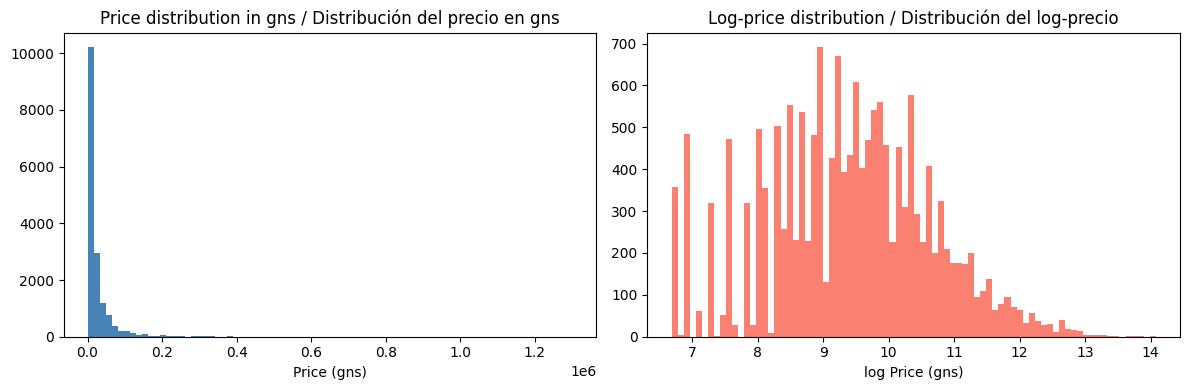

Skewness raw / asimetría bruta: 6.98
Skewness log / asimetría log: 0.03
Median vs mean / mediana vs media: 12,000 vs 26,334
P95 and P99 / percentiles 95 y 99: 95,000 / 240,000
Share above 100k gns / proporción por encima de 100k gns: 4.29%
Median sold price 95% CI / IC del 95% de la mediana vendida: 12,000 [12,000, 12,000] gns
Sale rate 95% CI / IC del 95% de la tasa de venta: 63.40% [62.78%, 63.95%]
Permutation test day(2-3) vs day(4-5) on log-price / prueba de permutación días(2-3) vs días(4-5): diff=1.224, p=0.0000
Permutation test colts vs fillies on log-price / prueba de permutación potros vs fillies: diff=0.887, p=0.0000


In [24]:
df_sold = autumn_horses_df.loc[autumn_horses_df['sold_to_third_party']].copy()
price_values = df_sold['price_gns'].dropna()
log_price = np.log(price_values[price_values > 0])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(price_values, bins=80, color='steelblue')
axes[0].set_title('Price distribution in gns / Distribución del precio en gns')
axes[0].set_xlabel('Price (gns)')

axes[1].hist(log_price, bins=80, color='salmon')
axes[1].set_title('Log-price distribution / Distribución del log-precio')
axes[1].set_xlabel('log Price (gns)')
plt.tight_layout()
plt.show()

median_price, median_ci_low, median_ci_high = bootstrap_ci(price_values, stat_func=np.median)
sale_rate, sale_rate_ci_low, sale_rate_ci_high = bootstrap_proportion_ci(autumn_horses_df['sold_to_third_party'])
day_gap, day_p_value = permutation_test(
    df_sold.loc[df_sold['day'].isin([2, 3]), 'log_price_gns'],
    df_sold.loc[df_sold['day'].isin([4, 5]), 'log_price_gns'],
    stat_func=np.median,
)
sex_gap, sex_p_value = permutation_test(
    df_sold.loc[df_sold['sex'] == 'C', 'log_price_gns'],
    df_sold.loc[df_sold['sex'] == 'F', 'log_price_gns'],
    stat_func=np.median,
)

print(f"Skewness raw / asimetría bruta: {price_values.skew():.2f}")
print(f"Skewness log / asimetría log: {log_price.skew():.2f}")
print(f"Median vs mean / mediana vs media: {price_values.median():,.0f} vs {price_values.mean():,.0f}")
print(f"P95 and P99 / percentiles 95 y 99: {price_values.quantile(0.95):,.0f} / {price_values.quantile(0.99):,.0f}")
print(f"Share above 100k gns / proporción por encima de 100k gns: {(price_values.gt(100_000).mean() * 100):.2f}%")
print(f"Median sold price 95% CI / IC del 95% de la mediana vendida: {median_price:,.0f} [{median_ci_low:,.0f}, {median_ci_high:,.0f}] gns")
print(f"Sale rate 95% CI / IC del 95% de la tasa de venta: {sale_rate * 100:.2f}% [{sale_rate_ci_low * 100:.2f}%, {sale_rate_ci_high * 100:.2f}%]")
print(f"Permutation test day(2-3) vs day(4-5) on log-price / prueba de permutación días(2-3) vs días(4-5): diff={day_gap:.3f}, p={day_p_value:.4f}")
print(f"Permutation test colts vs fillies on log-price / prueba de permutación potros vs fillies: diff={sex_gap:.3f}, p={sex_p_value:.4f}")

In [25]:
# 4. High-cardinality entities / Entidades de alta cardinalidad
print('=== TOP 15 CANONICAL SIRES / TOP 15 SIRES CANONICOS (median price, min 15 sales) ===')
sire_stats = (
    df_sold.groupby('sire_entity')
    .agg(
        sire_label=('sire_clean', lambda x: x.mode().iat[0] if not x.mode().empty else x.iloc[0]),
        median=('price_gns', 'median'),
        count=('price_gns', 'count')
    )
    .query('count >= 15')
    .sort_values(['median', 'count'], ascending=[False, False])
    .head(15)
)
display(sire_stats)

print('\n=== TOP 15 EXACT CONSIGNORS / TOP 15 CONSIGNORS EXACTOS (median price, min 20 sales) ===')
cons_stats_exact = (
    df_sold.groupby('consignor_entity_exact')
    .agg(
        consignor_label=('consignor_label', lambda x: x.mode().iat[0] if not x.mode().empty else x.iloc[0]),
        median=('price_gns', 'median'),
        count=('price_gns', 'count')
    )
    .query('count >= 20')
    .sort_values(['median', 'count'], ascending=[False, False])
    .head(15)
)
display(cons_stats_exact)

print('\n=== TOP 15 FAMILY-LEVEL CONSIGNORS / TOP 15 CONSIGNORS POR FAMILIA (supplementary only) ===')
cons_stats_family = (
    df_sold.groupby('consignor_family')
    .agg(median=('price_gns', 'median'), count=('price_gns', 'count'))
    .query('count >= 20')
    .sort_values(['median', 'count'], ascending=[False, False])
    .head(15)
)
display(cons_stats_family)

=== TOP 15 CANONICAL SIRES / TOP 15 SIRES CANONICOS (median price, min 15 sales) ===


,sire_label,median,count
sire_entity,,,
FRANKEL,Frankel,"32,000.00",109
POSTPONED,Postponed,"32,000.00",16
DUBAWI,Dubawi,"30,000.00",177
AZAMOUR,Azamour,"30,000.00",38
MIZZEN MAST,Mizzen Mast,"30,000.00",37
DYNAFORMER,Dynaformer,"30,000.00",21
FIRST DEFENCE,First Defence,"30,000.00",15
SIOUX NATION,Sioux Nation,"28,500.00",32
KENDARGENT,Kendargent,"28,500.00",16



=== TOP 15 EXACT CONSIGNORS / TOP 15 CONSIGNORS EXACTOS (median price, min 20 sales) ===


,consignor_label,median,count
consignor_entity_exact,,,
JUDDMONTE,Juddmonte,"60,000.00",50
IMPERIUM SALES,Imperium Sales,"50,000.00",40
MOYGLARE STUD FARM LTD.,Moyglare Stud Farm Ltd.,"33,500.00",26
COOLMORE,Coolmore,"31,000.00",115
"SOMERVILLE LODGE LTD., AGENT","Somerville Lodge Ltd., Agent","30,000.00",141
KINGSCLERE TRAINING STABLES,Kingsclere Training Stables,"26,500.00",60
"CURRABEG STABLES, IRELAND","Currabeg Stables, Ireland","25,000.00",32
JUDDMONTE FARMS,Juddmonte Farms,"22,000.00",457
FREEMASON LODGE STABLES,Freemason Lodge Stables,"22,000.00",214



=== TOP 15 FAMILY-LEVEL CONSIGNORS / TOP 15 CONSIGNORS POR FAMILIA (supplementary only) ===


,median,count
consignor_family,,
IMPERIUM SALES,"50,000.00",40
COOLMORE,"35,000.00",129
KINGSCLERE TRAINING,"26,500.00",60
CURRABEG,"25,000.00",32
JUDDMONTE,"24,000.00",507
MOYGLARE STUD FARM,"23,500.00",34
FREEMASON LODGE,"22,000.00",214
SHADWELL ESTATE,"22,000.00",198
BALLYDOYLE,"22,000.00",179


In [26]:
day_stats = df_sold.groupby('day')['price_gns'].agg(['mean', 'median', 'count', 'std']).round(0)
day_outcomes = autumn_horses_df.groupby('day').agg(
    total_catalogued=('day', 'size'),
    offered=('is_offered_for_sale', 'sum'),
    sold_to_third_party=('sold_to_third_party', 'sum'),
    vendor_buyback=('vendor_buyback', 'sum'),
    lot_not_sold=('lot_not_sold', 'sum'),
    withdrawn=('lot_withdrawn', 'sum')
)
day_outcomes['sale_rate_on_catalogue'] = 100 * day_outcomes['sold_to_third_party'] / day_outcomes['total_catalogued']
day_outcomes['sale_rate_on_offered'] = 100 * day_outcomes['sold_to_third_party'] / day_outcomes['offered']

display(day_stats)
display(day_outcomes.round(1))

,mean,median,count,std
day,,,,
1,"24,932.00","12,000.00",4135,"39,274.00"
2,"34,719.00","17,000.00",4180,"60,539.00"
3,"34,438.00","17,000.00",4574,"56,803.00"
4,"8,239.00","5,000.00",3261,"11,894.00"
5,"7,140.00","4,000.00",381,"8,533.00"


,total_catalogued,offered,sold_to_third_party,vendor_buyback,lot_not_sold,withdrawn,sale_rate_on_catalogue,sale_rate_on_offered
day,,,,,,,,
1,6823,4912,4135,487,290,1911,60.60,84.20
2,6472,4710,4180,338,192,1762,64.60,88.70
3,6770,5125,4574,310,241,1645,67.60,89.20
4,5289,3778,3261,210,307,1511,61.70,86.30
5,722,470,381,38,51,252,52.80,81.10


In [27]:
sex_price = df_sold.groupby('sex').agg(
    median_price=('price_gns', 'median'),
    count=('price_gns', 'count'),
    median_age=('age_at_sale', 'median')
)
sex_outcomes = autumn_horses_df.groupby('sex').agg(
    total=('sex', 'size'),
    offered=('is_offered_for_sale', 'sum'),
    sold_to_third_party=('sold_to_third_party', 'sum')
)
sex_outcomes['sale_rate_on_catalogue'] = 100 * sex_outcomes['sold_to_third_party'] / sex_outcomes['total']
sex_outcomes['sale_rate_on_offered'] = 100 * sex_outcomes['sold_to_third_party'] / sex_outcomes['offered']

print('Price profile by sex / Perfil de precio por sexo')
display(sex_price)
print('Outcome profile by sex / Perfil de outcome por sexo')
display(sex_outcomes.round(1))

Price profile by sex / Perfil de precio por sexo


,median_price,count,median_age
sex,,,
C,"17,000.00",4466,3.00
F,"7,000.00",4031,3.00
G,"13,000.00",7867,3.00
H,"22,000.00",88,5.00
M,"5,500.00",78,5.00
R,"45,000.00",1,3.00


Outcome profile by sex / Perfil de outcome por sexo


,total,offered,sold_to_third_party,sale_rate_on_catalogue,sale_rate_on_offered
sex,,,,,
C,7403,4951,4466,60.30,90.20
F,6331,4669,4031,63.70,86.30
G,12002,9148,7867,65.50,86.00
H,162,109,88,54.30,80.70
M,155,117,78,50.30,66.70
R,1,1,1,100.00,100.00


In [28]:
birth_year_stats = df_sold.groupby('birth_year')['price_gns'].agg(['median', 'count'])
age_stats = df_sold.groupby('age_at_sale')['price_gns'].agg(['median', 'count'])

print('Birth-year medians / Medianas por cohorte de nacimiento')
display(birth_year_stats)
print('Age-at-sale medians / Medianas por edad en la subasta')
display(age_stats)

Birth-year medians / Medianas por cohorte de nacimiento


,median,count
birth_year,,
2002,"3,500.00",4
2003,"4,000.00",15
2004,"14,000.00",48
2005,"13,000.00",185
2006,"10,000.00",629
2007,"8,500.00",929
2008,"8,000.00",865
2009,"11,000.00",954
2010,"11,000.00",835


Age-at-sale medians / Medianas por edad en la subasta


,median,count
age_at_sale,,
2,"10,000.00",4745
3,"13,000.00",8121
4,"15,000.00",2467
5,"14,000.00",766
6,"9,000.00",301
7,"8,000.00",99
8,"4,500.00",29
9,"1,000.00",3


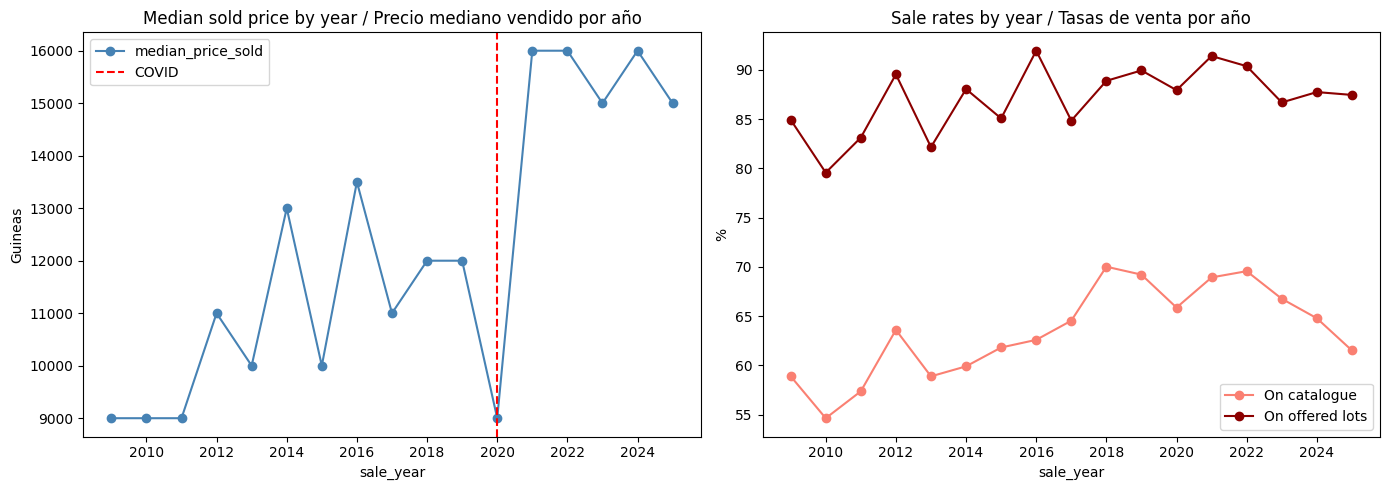

Median price by year and day / Precio mediano por año y día


day,1,2,3,4,5
sale_year,,,,,
2009,"10,000.00","13,250.00","14,500.00","3,500.00",<NA>
2010,"8,750.00","13,000.00","11,000.00","2,900.00",<NA>
2011,"9,250.00","12,000.00","9,250.00","3,200.00",<NA>
2012,"12,500.00","14,000.00","13,000.00","4,000.00",<NA>
2013,"10,000.00","16,000.00","14,000.00","4,000.00",<NA>
2014,"14,000.00","16,000.00","20,000.00","4,500.00",<NA>
2015,"12,000.00","13,500.00","15,000.00","4,000.00",<NA>
2016,"13,500.00","19,000.00","17,000.00","7,000.00",<NA>
2017,"14,000.00","18,000.00","22,000.00","5,500.00","3,000.00"


In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

by_year['median_price_sold'].plot(ax=axes[0], marker='o', color='steelblue')
axes[0].set_title('Median sold price by year / Precio mediano vendido por año')
axes[0].set_ylabel('Guineas')
axes[0].axvline(x=2020, color='red', linestyle='--', label='COVID')
axes[0].legend()

by_year['sale_rate_on_catalogue'].plot(ax=axes[1], marker='o', color='salmon', label='On catalogue')
by_year['sale_rate_on_offered'].plot(ax=axes[1], marker='o', color='darkred', label='On offered lots')
axes[1].set_title('Sale rates by year / Tasas de venta por año')
axes[1].set_ylabel('%')
axes[1].legend()
plt.tight_layout()
plt.show()

day_year_pivot = df_sold.pivot_table(index='sale_year', columns='day', values='price_gns', aggfunc='median')
print('Median price by year and day / Precio mediano por año y día')
display(day_year_pivot)

In [30]:
foaling_stats = df_sold.groupby('foaled_month').agg(
    median_price=('price_gns', 'median'),
    count=('price_gns', 'count')
)
foaling_outcomes = autumn_horses_df.loc[autumn_horses_df['foaled_month'].notna()].groupby('foaled_month').agg(
    total=('foaled_month', 'size'),
    sold_to_third_party=('sold_to_third_party', 'sum')
)
foaling_outcomes['sale_rate'] = 100 * foaling_outcomes['sold_to_third_party'] / foaling_outcomes['total']

print('Foaling month profile / Perfil por mes de nacimiento')
display(foaling_stats)
display(foaling_outcomes.round(1))

Foaling month profile / Perfil por mes de nacimiento


,median_price,count
foaled_month,,
1,"11,000.00",1251
2,"12,000.00",4232
3,"12,000.00",5166
4,"12,000.00",4609
5,"12,000.00",1248
6,"8,000.00",13
8,"4,500.00",3
9,"8,000.00",3
10,"14,000.00",5


,total,sold_to_third_party,sale_rate
foaled_month,,,
1,1958,1251,63.90
2,6641,4232,63.70
3,8128,5166,63.60
4,7304,4609,63.10
5,1972,1248,63.30
6,27,13,48.10
7,2,0,0.00
8,3,3,100.00
9,6,3,50.00


In [31]:
print('=== SUMMARY / RESUMEN ===')
print(f"Rows / registros: {len(autumn_horses_df):,}")
print(f"Period / periodo: {autumn_horses_df['sale_year'].min()} - {autumn_horses_df['sale_year'].max()}")
print(f"Sold to third parties / vendidos a terceros: {autumn_horses_df['sold_to_third_party'].sum():,} ({autumn_horses_df['sold_to_third_party'].mean()*100:.1f}%)")
print(f"Vendor buybacks / recompras del vendor: {autumn_horses_df['vendor_buyback'].sum():,}")
print(f"Lot not sold / lotes no vendidos: {autumn_horses_df['lot_not_sold'].sum():,}")
print(f"Withdrawn / retirados: {autumn_horses_df['lot_withdrawn'].sum():,}")
print(f"Median sold price / precio mediano vendido: {df_sold['price_gns'].median():,.0f} gns")
print(f"Maximum sold price / precio máximo vendido: {df_sold['price_gns'].max():,.0f} gns")
print(f"Observed foaling dates / fechas de nacimiento observadas: {autumn_horses_df['date_foaled'].notna().sum():,}")
print(f"Unique sires canonical / sires únicos canónicos: {autumn_horses_df['sire_entity'].nunique():,}")
print(f"Unique consignors raw / consignors raw únicos: {autumn_horses_df['consignor'].nunique():,}")
print(f"Unique consignors exact canonical / consignors exactos canónicos: {autumn_horses_df['consignor_entity_exact'].nunique():,}")
print(f"Unique consignor families / familias de consignor: {autumn_horses_df['consignor_family'].nunique():,}")
print('Use guineas for historical comparison / usar guineas para comparación histórica.')

leakage_audit = pd.DataFrame([
    ('price_gns', 'target_or_post_sale', 'Use only as regression target on sold lots / usar solo como objetivo de regresión sobre vendidos'),
    ('price_euros', 'descriptive_only', 'Not for core historical modeling / no para modelado histórico principal'),
    ('purchaser', 'leaky', 'Contains post-outcome information / contiene información posterior al outcome'),
    ('sale_outcome', 'leaky', 'Derived from purchaser and price / derivado de purchaser y precio'),
    ('sold_to_third_party', 'target', 'Classification target only / solo objetivo de clasificación'),
    ('vendor_buyback', 'target_family', 'Outcome-derived / derivado del resultado'),
    ('log_price_gns', 'target', 'Regression target only / solo objetivo de regresión'),
    ('consignor_model', 'safe_feature', 'Safe if used as pre-sale metadata / segura como metadato pre-venta'),
    ('sire_model', 'safe_feature', 'Safe pedigree feature / variable segura de pedigree'),
    ('day', 'proxy_feature', 'Useful but partially endogenous / útil pero parcialmente endógena'),
], columns=['column', 'status', 'note'])

print('\nFeature audit / Auditoría de variables')
display(leakage_audit)

=== SUMMARY / RESUMEN ===
Rows / registros: 26,076
Period / periodo: 2009 - 2025
Sold to third parties / vendidos a terceros: 16,531 (63.4%)
Vendor buybacks / recompras del vendor: 1,383
Lot not sold / lotes no vendidos: 1,081
Withdrawn / retirados: 7,081
Median sold price / precio mediano vendido: 12,000 gns
Maximum sold price / precio máximo vendido: 1,300,000 gns
Observed foaling dates / fechas de nacimiento observadas: 26,054
Unique sires canonical / sires únicos canónicos: 997
Unique consignors raw / consignors raw únicos: 967
Unique consignors exact canonical / consignors exactos canónicos: 840
Unique consignor families / familias de consignor: 781
Use guineas for historical comparison / usar guineas para comparación histórica.

Feature audit / Auditoría de variables


,column,status,note
0,price_gns,target_or_post_sale,Use only as regression target on sold lots / u...
1,price_euros,descriptive_only,Not for core historical modeling / no para mod...
2,purchaser,leaky,Contains post-outcome information / contiene i...
3,sale_outcome,leaky,Derived from purchaser and price / derivado de...
4,sold_to_third_party,target,Classification target only / solo objetivo de ...
5,vendor_buyback,target_family,Outcome-derived / derivado del resultado
6,log_price_gns,target,Regression target only / solo objetivo de regr...
7,consignor_model,safe_feature,Safe if used as pre-sale metadata / segura com...
8,sire_model,safe_feature,Safe pedigree feature / variable segura de ped...
9,day,proxy_feature,Useful but partially endogenous / útil pero pa...


In [32]:
print('=== ENTITY NORMALIZATION STRATEGY / ESTRATEGIA DE NORMALIZACIÓN ===')
print('No row-order realignment is used in the final pipeline.')
print('No se usa ninguna realineación por orden de filas en el pipeline final.')
print('Consignor exact canonical source / fuente canónica exacta de consignor: consignor_n (embedded BREEDER_N).')
print('Consignor family labels are supplementary aggregations, not exact identities.')
print('Las familias de consignor son agregaciones auxiliares, no identidades exactas.')
print('Sire canonical source / fuente canónica de sire: sire_n (embedded SIRE_N).')
print('Display labels stay human-readable, while model labels stay canonical.')
print('Las etiquetas para mostrar siguen siendo legibles, mientras que las del modelo permanecen canónicas.')

=== ENTITY NORMALIZATION STRATEGY / ESTRATEGIA DE NORMALIZACIÓN ===
No row-order realignment is used in the final pipeline.
No se usa ninguna realineación por orden de filas en el pipeline final.
Consignor exact canonical source / fuente canónica exacta de consignor: consignor_n (embedded BREEDER_N).
Consignor family labels are supplementary aggregations, not exact identities.
Las familias de consignor son agregaciones auxiliares, no identidades exactas.
Sire canonical source / fuente canónica de sire: sire_n (embedded SIRE_N).
Display labels stay human-readable, while model labels stay canonical.
Las etiquetas para mostrar siguen siendo legibles, mientras que las del modelo permanecen canónicas.


In [33]:
# Exploracion inicial por similitud de strings.
# Util para detectar alias obvios, pero NO es la version final que se usara en modelado.
# La version final de consignor se construye en la celda siguiente apoyandose en BREEDER_N.

import re
from itertools import combinations
import pandas as pd

# Fallback: usa RapidFuzz si está disponible; si no, usa difflib
try:
    from rapidfuzz import fuzz
    def similarity(a, b):
        return fuzz.token_set_ratio(a, b)
    matcher_name = "rapidfuzz.token_set_ratio"
except ImportError:
    from difflib import SequenceMatcher
    def similarity(a, b):
        return round(100 * SequenceMatcher(None, a, b).ratio(), 1)
    matcher_name = "difflib.SequenceMatcher"

print(f"Matcher usado: {matcher_name}")

# Tokens que suelen meter ruido y no identifican bien la entidad
STOPWORDS = {
    "ltd", "limited", "company", "co", "inc",
    "farm", "farms", "stud", "stables", "stable",
    "racing", "bloodstock", "consignment", "agent",
    "ireland", "england", "gb", "uk", "lodge", "house"
}

def normalize_consignor(name: str) -> str:
    if pd.isna(name):
        return None
    
    s = str(name).lower().strip()
    
    # Quita contenido entre paréntesis: trainers, agents, localizaciones, etc.
    s = re.sub(r"\(.*?\)", " ", s)
    
    # Estandariza símbolos
    s = s.replace("&", " and ")
    s = re.sub(r"[^a-z0-9\s]", " ", s)
    
    tokens = [t for t in s.split() if t not in STOPWORDS]
    s = " ".join(tokens)
    s = re.sub(r"\s+", " ", s).strip()
    
    return s if s else None

# Base única de consignors
cons_df = (
    autumn_horses_df.loc[autumn_horses_df["consignor"].notna(), ["consignor", "sale_year"]]
    .copy()
)

name_stats = (
    cons_df.groupby("consignor")
    .agg(
        n_rows=("consignor", "size"),
        first_year=("sale_year", "min"),
        last_year=("sale_year", "max"),
        n_years=("sale_year", "nunique"),
    )
    .reset_index()
)

name_stats["canon"] = name_stats["consignor"].map(normalize_consignor)
name_stats["block"] = name_stats["canon"].str.split().str[0].fillna("")

# 1) Grupos obvios por normalización exacta
canonical_groups = (
    name_stats.groupby("canon")
    .agg(
        n_variants=("consignor", "nunique"),
        total_rows=("n_rows", "sum"),
        names=("consignor", lambda x: sorted(set(x))),
    )
    .reset_index()
)

obvious_aliases = canonical_groups[
    canonical_groups["canon"].notna() &
    (canonical_groups["n_variants"] > 1)
].sort_values(["n_variants", "total_rows"], ascending=[False, False])

print("=== Grupos obvios por canon exacto ===")
display(obvious_aliases.head(30))

# 2) Candidatos fuzzy dentro de bloques
# Solo comparamos nombres dentro del mismo "block" para reducir ruido.
candidate_pairs = []

for block, g in name_stats.groupby("block"):
    if not block or len(g) < 2:
        continue
    
    rows = g[["consignor", "canon", "n_rows", "first_year", "last_year", "n_years"]].to_dict("records")
    
    for a, b in combinations(rows, 2):
        if pd.isna(a["canon"]) or pd.isna(b["canon"]):
            continue
        
        # Similaridad sobre nombre canónico
        score_canon = similarity(a["canon"], b["canon"])
        
        # Similaridad sobre raw, por si ayuda
        score_raw = similarity(a["consignor"].lower(), b["consignor"].lower())
        
        score = max(score_canon, score_raw)
        
        # Heurística adicional: si comparten exactamente canon, no hace falta fuzzy
        same_canon = a["canon"] == b["canon"]
        if same_canon:
            continue
        
        # Solape temporal simple para ayudar a interpretar
        overlap_years = not (
            a["last_year"] < b["first_year"] or b["last_year"] < a["first_year"]
        )
        
        # Filtro razonable
        if score >= 88:
            candidate_pairs.append({
                "name_a": a["consignor"],
                "name_b": b["consignor"],
                "canon_a": a["canon"],
                "canon_b": b["canon"],
                "score": score,
                "score_canon": score_canon,
                "score_raw": score_raw,
                "rows_a": a["n_rows"],
                "rows_b": b["n_rows"],
                "years_a": f"{a['first_year']}-{a['last_year']}",
                "years_b": f"{b['first_year']}-{b['last_year']}",
                "overlap_years": overlap_years,
                "block": block,
            })

candidates_df = pd.DataFrame(candidate_pairs)

if len(candidates_df) == 0:
    print("No se encontraron candidatos fuzzy con el umbral actual.")
else:
    candidates_df = candidates_df.sort_values(
        ["score", "overlap_years", "rows_a", "rows_b"],
        ascending=[False, False, False, False]
    )
    print("=== Candidatos fuzzy para revisión manual ===")
    display(candidates_df.head(100))

# 3) Revisión específica de strings que contengan palabras clave
keywords = ["juddmonte", "shadwell", "coolmore", "somerville", "castlebridge", "kingsley", "carlburg"]
keyword_view = name_stats[
    name_stats["consignor"].str.lower().str.contains("|".join(keywords), na=False)
].sort_values(["canon", "n_rows"], ascending=[True, False])

print("=== Vista rápida por keywords ===")
display(keyword_view)

Matcher usado: rapidfuzz.token_set_ratio
=== Grupos obvios por canon exacto ===


,canon,n_variants,total_rows,names
600,saffron,6,64,"[Saffron House Stables (G. Boughey), Saffron H..."
298,grange,5,95,"[Grange Farm Racing Stables, Ireland (D. M. Lo..."
447,manor,5,28,"[Manor Farm (Wiltshire), Manor Farm Stables (P..."
325,harraton court,5,20,"[Harraton Court Stables (D. Holland), Harraton..."
289,glebe,4,193,"[Glebe House Stables (J. Santos), Glebe House ..."
41,averham park,4,67,"[Averham Park Racing Stables (A. McCabe), Aver..."
238,exeter,4,40,"[Exeter House Stables (P. J. McBride), Exeter ..."
105,cadland cottage,4,32,"[Cadland Cottage Stables (D. Quinn), Cadland C..."
569,red,4,20,"[Red House Stables (Dr J. Scargill), Red House..."
324,harraton,4,7,"[Harraton Racing Ltd., Harraton Stud (J. Feild..."


=== Candidatos fuzzy para revisión manual ===


,name_a,name_b,canon_a,canon_b,score,score_canon,score_raw,rows_a,rows_b,years_a,years_b,overlap_years,block
60,"Heath House Stables (Sir Mark Prescott, Bt.)",Heath View Stables (L. McJannet),heath,heath view,100.00,100.00,57.78,322,2,2009-2025,2019-2019,True,heath
22,Exeter House Stables (P. J. McBride),Exeter Ride (M. Tompkins),exeter,exeter ride,100.00,100.00,55.74,36,15,2011-2025,2013-2015,True,exeter
74,Manton Lodge Stables (B. Meehan),Manton Park Racing Ltd.,manton,manton park,100.00,100.00,47.27,33,13,2020-2022,2021-2021,True,manton
38,Hamilton Stables (M. Wigham),"Hamilton Stables, Compton (J. Portman)",hamilton,hamilton compton,100.00,100.00,57.58,33,10,2010-2021,2009-2011,True,hamilton
73,Manton Lodge Stables (B. Meehan),Manton Park Racing (M. Meade),manton,manton park,100.00,100.00,52.46,33,3,2020-2022,2020-2020,True,manton
...,...,...,...,...,...,...,...,...,...,...,...,...,...
35,Grange Hill Farm Ltd. (N. Twiston-Davies),Grange House Stables (P. Charamlambous),grange hill,grange,100.00,100.00,52.50,1,1,2016-2016,2012-2012,False,grange
50,Harraton Court Stables (M. Moubarak),Harraton Stud (Miss J. Feilden),harraton court,harraton,100.00,100.00,47.76,1,1,2017-2017,2009-2009,False,harraton
51,Harraton Court Stables (M. Moubarak),Harraton Stud (Mrs J. Feilden),harraton court,harraton,100.00,100.00,51.52,1,1,2017-2017,2010-2010,False,harraton
86,Pond House Stables (D. Quinn),"Pond House Stables, Newmarket (K. Clutterbuck)",pond,pond newmarket,100.00,100.00,64.00,1,1,2023-2023,2013-2013,False,pond


=== Vista rápida por keywords ===


,consignor,n_rows,first_year,last_year,n_years,canon,block
135,Carlburg Stables (R. Varian),172,2017,2021,5,carlburg,carlburg
134,Carlburg Stables (C. Brittain),55,2009,2015,6,carlburg,carlburg
188,Coolmore,227,2021,2025,4,coolmore,coolmore
189,"Coolmore, Ireland",45,2022,2022,1,coolmore,coolmore
506,Juddmonte Farms,561,2009,2022,14,juddmonte,juddmonte
505,Juddmonte,62,2023,2025,3,juddmonte,juddmonte
524,Kingsley House Stables (M. Johnston),300,2009,2017,9,kingsley,kingsley
523,Kingsley House (M. Johnston),31,2018,2018,1,kingsley,kingsley
525,Kingsley Park,309,2019,2025,7,kingsley park,kingsley
791,Shadwell Stud,683,2009,2019,11,shadwell,shadwell


In [34]:
# English: exact consignor identity and family-level aggregation must stay separate.
# Español: la identidad exacta de consignor y la agregación por familia deben mantenerse separadas.
print('=== CONSIGNOR COUNTS ===')
print(f"Raw consignor unique / consignor raw únicos: {autumn_horses_df['consignor'].nunique():,}")
print(f"Exact canonical consignor unique / consignor exacto canónico único: {autumn_horses_df['consignor_entity_exact'].nunique():,}")
print(f"Family-level consignor unique / familia de consignor única: {autumn_horses_df['consignor_family'].nunique():,}")

focus_families = ['JUDDMONTE', 'SOMERVILLE LODGE', 'COOLMORE', 'BALLYDOYLE', 'CARLBURG', 'JAMIE RAILTON', 'KINGSLEY HOUSE']
focus_examples = (
    autumn_horses_df.loc[autumn_horses_df['consignor_family'].isin(focus_families), ['consignor', 'consignor_entity_exact', 'consignor_label', 'consignor_family']]
    .drop_duplicates()
    .sort_values(['consignor_family', 'consignor'])
)

print('\n=== FAMILY EXAMPLES / EJEMPLOS DE FAMILIA ===')
display(focus_examples)

consignor_family_review = (
    autumn_horses_df.groupby('consignor_family')
    .agg(
        n_rows=('consignor_family', 'size'),
        n_exact_entities=('consignor_entity_exact', 'nunique'),
        exact_examples=('consignor_entity_exact', lambda x: sorted(pd.Series(x).dropna().unique())[:6]),
        raw_examples=('consignor', lambda x: sorted(pd.Series(x).dropna().unique())[:6])
    )
    .reset_index()
    .sort_values(['n_exact_entities', 'n_rows'], ascending=[False, False])
)

print('\n=== FAMILIES THAT MERGE MULTIPLE EXACT ENTITIES / FAMILIAS QUE FUSIONAN MÚLTIPLES ENTIDADES EXACTAS ===')
display(consignor_family_review[consignor_family_review['n_exact_entities'] > 1].head(30))


=== CONSIGNOR COUNTS ===
Raw consignor unique / consignor raw únicos: 967
Exact canonical consignor unique / consignor exacto canónico único: 840
Family-level consignor unique / familia de consignor única: 781

=== FAMILY EXAMPLES / EJEMPLOS DE FAMILIA ===


,consignor,consignor_entity_exact,consignor_label,consignor_family
960,Ballydoyle Racing,BALLYDOYLE RACING,Ballydoyle Racing,BALLYDOYLE
128,"Ballydoyle Stables, Ireland (A. O'Brien)","BALLYDOYLE STABLES, IRELAND","Ballydoyle Stables, Ireland",BALLYDOYLE
23452,"Ballydoyle Stables, Ireland (Agent)","BALLYDOYLE STABLES, IRELAND","Ballydoyle Stables, Ireland",BALLYDOYLE
15410,Carlburg Stables (C. Brittain),CARLBURG STABLES,Carlburg Stables,CARLBURG
19,Carlburg Stables (R. Varian),CARLBURG STABLES,Carlburg Stables,CARLBURG
146,Coolmore,COOLMORE,Coolmore,COOLMORE
814,"Coolmore, Ireland","COOLMORE, IRELAND","Coolmore, Ireland",COOLMORE
20,Jamie Railton (Agent),JAMIE RAILTON,Jamie Railton,JAMIE RAILTON
18583,"Jamie Railton, Agent","JAMIE RAILTON, AGENT","Jamie Railton, Agent",JAMIE RAILTON
0,Juddmonte,JUDDMONTE,Juddmonte,JUDDMONTE



=== FAMILIES THAT MERGE MULTIPLE EXACT ENTITIES / FAMILIAS QUE FUSIONAN MÚLTIPLES ENTIDADES EXACTAS ===


,consignor_family,n_rows,n_exact_entities,exact_examples,raw_examples
291,GEORGE BAKER,118,3,"[GEORGE BAKER RACING, GEORGE BAKER RACING LLP,...","[George Baker Racing, George Baker Racing LLP,..."
608,ROBINS FARM,54,3,"[ROBINS FARM, ROBINS FARM RACING, ROBINS FARM ...","[Robins Farm (G. Baker), Robins Farm Racing (O..."
394,JAMIE RAILTON,883,2,"[JAMIE RAILTON, JAMIE RAILTON, AGENT]","[Jamie Railton (Agent), Jamie Railton, Agent]"
410,JUDDMONTE,623,2,"[JUDDMONTE, JUDDMONTE FARMS]","[Juddmonte, Juddmonte Farms]"
657,SOMERVILLE LODGE,516,2,"[SOMERVILLE LODGE LTD., SOMERVILLE LODGE LTD.,...","[Somerville Lodge Ltd. (W. Haggas), Somerville..."
49,BALLYDOYLE,485,2,"[BALLYDOYLE RACING, BALLYDOYLE STABLES, IRELAND]","[Ballydoyle Racing, Ballydoyle Stables, Irelan..."
425,KINGSLEY HOUSE,331,2,"[KINGSLEY HOUSE, KINGSLEY HOUSE STABLES]","[Kingsley House (M. Johnston), Kingsley House ..."
154,COOLMORE,272,2,"[COOLMORE, COOLMORE, IRELAND]","[Coolmore, Coolmore, Ireland]"
261,FITZROY HOUSE,247,2,"[FITZROY HOUSE, FITZROY HOUSE STABLES]","[Fitzroy House (M. Bell), Fitzroy House Stable..."
465,MANOR HOUSE,226,2,"[MANOR HOUSE STABLES, MANOR HOUSE STABLES LLP]","[Manor House Stables (J. Ward), Manor House St..."


In [35]:
# English: final sire normalization also relies on the canonical field already present in the file.
# Español: la normalización final de sire también se apoya en el campo canónico ya presente en el fichero.
autumn_horses_df['sire_raw'] = autumn_horses_df['sire']
autumn_horses_df['sire_entity'] = autumn_horses_df['sire_n'].fillna(autumn_horses_df['sire'].str.upper())
raw_sire_labels = strip_country_suffix(autumn_horses_df['sire_raw'])
preferred_sire_label = (
    pd.DataFrame({'sire_entity': autumn_horses_df['sire_entity'], 'sire_label_candidate': raw_sire_labels})
    .dropna()
    .groupby('sire_entity')['sire_label_candidate']
    .agg(lambda x: x.value_counts().index[0])
)
autumn_horses_df['sire_label'] = autumn_horses_df['sire_entity'].map(preferred_sire_label).fillna(title_from_canonical(autumn_horses_df['sire_entity']))
autumn_horses_df['sire_clean'] = autumn_horses_df['sire_label']
autumn_horses_df['sire_model'] = autumn_horses_df['sire_entity']

print('=== SIRE COUNTS ===')
print(f"Raw sire unique / sire raw únicos: {autumn_horses_df['sire_raw'].nunique():,}")
print(f"Readable sire unique / sire legible único: {autumn_horses_df['sire_clean'].nunique():,}")
print(f"Canonical sire unique / sire canónico único: {autumn_horses_df['sire_entity'].nunique():,}")

sire_review = (
    autumn_horses_df[['sire_raw', 'sire_clean', 'sire_entity']]
    .dropna()
    .drop_duplicates()
    .groupby('sire_entity')
    .agg(
        n_raw_variants=('sire_raw', 'nunique'),
        raw_variants=('sire_raw', lambda x: sorted(set(x))),
        n_clean_variants=('sire_clean', 'nunique'),
        clean_variants=('sire_clean', lambda x: sorted(set(x)))
    )
    .reset_index()
    .sort_values(['n_raw_variants', 'sire_entity'], ascending=[False, True])
)

print('\n=== SIRES WITH MORE THAN ONE RAW LABEL / SIRES CON MÁS DE UNA GRAFÍA RAW ===')
display(sire_review[sire_review['n_raw_variants'] > 1].head(20))
print('\n=== CANONICAL SIRES WITH MORE THAN ONE DISPLAY LABEL / SIRES CANÓNICOS CON MÁS DE UNA ETIQUETA LEGIBLE ===')
display(sire_review[sire_review['n_clean_variants'] > 1].head(20))

print('\n=== EXAMPLES OF FINAL SIRE LABELS / EJEMPLOS DE ETIQUETAS FINALES ===')
display(
    autumn_horses_df[['sire_raw', 'sire_clean', 'sire_entity']]
    .dropna()
    .drop_duplicates()
    .sort_values('sire_entity')
    .head(20)
)


=== SIRE COUNTS ===
Raw sire unique / sire raw únicos: 997
Readable sire unique / sire legible único: 997
Canonical sire unique / sire canónico único: 997

=== SIRES WITH MORE THAN ONE RAW LABEL / SIRES CON MÁS DE UNA GRAFÍA RAW ===


,sire_entity,n_raw_variants,raw_variants,n_clean_variants,clean_variants
686,PIONEEROF THE NILE,2,"[Pioneerof The Nile (USA), Pioneerof the Nile ...",1,[Pioneerof The Nile]



=== CANONICAL SIRES WITH MORE THAN ONE DISPLAY LABEL / SIRES CANÓNICOS CON MÁS DE UNA ETIQUETA LEGIBLE ===


,sire_entity,n_raw_variants,raw_variants,n_clean_variants,clean_variants



=== EXAMPLES OF FINAL SIRE LABELS / EJEMPLOS DE ETIQUETAS FINALES ===


,sire_raw,sire_clean,sire_entity
17794,A P Indy (USA),A P Indy,A P INDY
13998,A'Ali (IRE),A'Ali,A'ALI
85,Acclamation (GB),Acclamation,ACCLAMATION
939,Aclaim (IRE),Aclaim,ACLAIM
21229,Act One (GB),Act One,ACT ONE
24424,Acteur Francais (USA),Acteur Francais,ACTEUR FRANCAIS
23714,Action This Day (USA),Action This Day,ACTION THIS DAY
15864,Ad Valorem (USA),Ad Valorem,AD VALOREM
195,Adaay (IRE),Adaay,ADAAY
5471,Adlerflug (GER),Adlerflug,ADLERFLUG


In [36]:
# Stability of entity rankings across periods / Estabilidad temporal de rankings

df_sold_norm = autumn_horses_df.loc[autumn_horses_df['sold_to_third_party']].copy()
early_period = df_sold_norm.loc[df_sold_norm['sale_year'].between(2009, 2015)]
recent_period = df_sold_norm.loc[df_sold_norm['sale_year'].between(2021, 2025)]

early_consignor_share = mean_annual_share_table(early_period, 'consignor_entity_exact', label_col='consignor_label').head(10)
recent_consignor_share = mean_annual_share_table(recent_period, 'consignor_entity_exact', label_col='consignor_label').head(10)
early_sire_share = mean_annual_share_table(early_period, 'sire_entity', label_col='sire_clean').head(10)
recent_sire_share = mean_annual_share_table(recent_period, 'sire_entity', label_col='sire_clean').head(10)

print('Top-10 exact consignor overlap / solapamiento de top-10 consignors exactos:', len(set(early_consignor_share.index) & set(recent_consignor_share.index)))
print('Top-10 sire overlap / solapamiento de top-10 sires:', len(set(early_sire_share.index) & set(recent_sire_share.index)))

print('\nEarly vs recent exact consignor leaders by mean annual share / Lideres exactos de consignor por cuota media anual')
display(pd.concat([
    early_consignor_share[['consignor_label', 'mean_annual_share', 'total_sales']].add_prefix('2009_2015_'),
    recent_consignor_share[['consignor_label', 'mean_annual_share', 'total_sales']].add_prefix('2021_2025_')
], axis=1).fillna(0))

print('\nEarly vs recent sire leaders by mean annual share / Lideres de sire por cuota media anual')
display(pd.concat([
    early_sire_share[['sire_clean', 'mean_annual_share', 'total_sales']].add_prefix('2009_2015_'),
    recent_sire_share[['sire_clean', 'mean_annual_share', 'total_sales']].add_prefix('2021_2025_')
], axis=1).fillna(0))


Top-10 exact consignor overlap / solapamiento de top-10 consignors exactos: 3
Top-10 sire overlap / solapamiento de top-10 sires: 1

Early vs recent exact consignor leaders by mean annual share / Lideres exactos de consignor por cuota media anual


,2009_2015_consignor_label,2009_2015_mean_annual_share,2009_2015_total_sales,2021_2025_consignor_label,2021_2025_mean_annual_share,2021_2025_total_sales
consignor_entity_exact,,,,,,
JAMIE RAILTON,Jamie Railton,0.06,114.00,Jamie Railton,0.05,242.00
EAST EVERLEIGH STABLES,East Everleigh Stables,0.06,356.00,East Everleigh Stables,0.03,132.00
JUDDMONTE FARMS,Juddmonte Farms,0.05,304.00,0,0.00,0.00
SHADWELL STUD,Shadwell Stud,0.04,272.00,0,0.00,0.00
"FINDLAY AND BLOOM, PART OF A DISPERSAL","Findlay And Bloom, Part Of A Dispersal",0.04,36.00,0,0.00,0.00
THE CASTLEBRIDGE CONSIGNMENT,The Castlebridge Consignment,0.03,96.00,The Castlebridge Consignment,0.11,576.00
BEDFORD HOUSE STABLES,Bedford House Stables,0.02,154.00,0,0.00,0.00
KINGSLEY HOUSE STABLES,Kingsley House Stables,0.02,133.00,0,0.00,0.00
WHITSBURY MANOR STABLES,Whitsbury Manor Stables,0.02,36.00,0,0.00,0.00



Early vs recent sire leaders by mean annual share / Lideres de sire por cuota media anual


,2009_2015_sire_clean,2009_2015_mean_annual_share,2009_2015_total_sales,2021_2025_sire_clean,2021_2025_mean_annual_share,2021_2025_total_sales
sire_entity,,,,,,
ACCLAMATION,Acclamation,0.02,136.00,0,0.00,0.00
OASIS DREAM,Oasis Dream,0.02,123.00,Oasis Dream,0.02,78.00
ROYAL APPLAUSE,Royal Applause,0.02,122.00,0,0.00,0.00
DANEHILL DANCER,Danehill Dancer,0.02,113.00,0,0.00,0.00
ZEBEDEE,Zebedee,0.02,35.00,0,0.00,0.00
EXCEED AND EXCEL,Exceed And Excel,0.02,110.00,0,0.00,0.00
GALILEO,Galileo,0.02,105.00,0,0.00,0.00
INVINCIBLE SPIRIT,Invincible Spirit,0.02,101.00,0,0.00,0.00
DANSILI,Dansili,0.02,101.00,0,0.00,0.00


In [37]:
# Historical vs recent comparison / Comparación histórica vs reciente
early_median, early_median_low, early_median_high = bootstrap_ci(early_period['price_gns'], stat_func=np.median)
recent_median, recent_median_low, recent_median_high = bootstrap_ci(recent_period['price_gns'], stat_func=np.median)
early_sale_rate, early_sale_rate_low, early_sale_rate_high = bootstrap_proportion_ci(
    autumn_horses_df.loc[autumn_horses_df['sale_year'].between(2009, 2015), 'sold_to_third_party']
)
recent_sale_rate, recent_sale_rate_low, recent_sale_rate_high = bootstrap_proportion_ci(
    autumn_horses_df.loc[autumn_horses_df['sale_year'].between(2021, 2025), 'sold_to_third_party']
)
period_log_gap, period_log_p_value = permutation_test(early_period['log_price_gns'], recent_period['log_price_gns'], stat_func=np.median)

period_summary = pd.DataFrame({
    '2009_2015': {
        'median_price_gns': early_median,
        'median_price_ci_low': early_median_low,
        'median_price_ci_high': early_median_high,
        'sale_rate_on_catalogue_pct': early_sale_rate * 100,
        'sale_rate_ci_low_pct': early_sale_rate_low * 100,
        'sale_rate_ci_high_pct': early_sale_rate_high * 100,
        'median_age_at_sale': early_period['age_at_sale'].median(),
        'mean_price_gns': early_period['price_gns'].mean(),
    },
    '2021_2025': {
        'median_price_gns': recent_median,
        'median_price_ci_low': recent_median_low,
        'median_price_ci_high': recent_median_high,
        'sale_rate_on_catalogue_pct': recent_sale_rate * 100,
        'sale_rate_ci_low_pct': recent_sale_rate_low * 100,
        'sale_rate_ci_high_pct': recent_sale_rate_high * 100,
        'median_age_at_sale': recent_period['age_at_sale'].median(),
        'mean_price_gns': recent_period['price_gns'].mean(),
    }
})

day_period_summary = pd.concat([
    early_period.groupby('day')['price_gns'].median().rename('median_2009_2015'),
    recent_period.groupby('day')['price_gns'].median().rename('median_2021_2025'),
    early_period.groupby('day').size().rename('count_2009_2015'),
    recent_period.groupby('day').size().rename('count_2021_2025')
], axis=1)

print('Historical vs recent summary / Resumen histórico vs reciente')
display(period_summary.round(2))
print(f"Permutation test early vs recent log-price / prueba de permutación histórica vs reciente en log-precio: diff={period_log_gap:.3f}, p={period_log_p_value:.4f}")
print('Day-level historical vs recent medians / Medianas por día históricas vs recientes')
display(day_period_summary.round(2))

print('\nTop 5 historical third-party sales / Top 5 ventas históricas a terceros:')
print(df_sold_norm.nlargest(5, 'price_gns')[['horse_name_clean', 'sire_clean', 'consignor_label', 'sale_year', 'day', 'price_gns']].to_string(index=False))

Historical vs recent summary / Resumen histórico vs reciente


,2009_2015,2021_2025
median_price_gns,"10,000.00","16,000.00"
median_price_ci_low,"10,000.00","15,000.00"
median_price_ci_high,"10,000.00","16,000.00"
sale_rate_on_catalogue_pct,59.29,66.18
sale_rate_ci_low_pct,58.38,65.16
sale_rate_ci_high_pct,60.22,67.20
median_age_at_sale,3.00,3.00
mean_price_gns,"21,616.75","33,319.65"


Permutation test early vs recent log-price / prueba de permutación histórica vs reciente en log-precio: diff=-0.470, p=0.0000
Day-level historical vs recent medians / Medianas por día históricas vs recientes


,median_2009_2015,median_2021_2025,count_2009_2015,count_2021_2025
day,,,,
1,"10,000.00","16,000.00","1,643.00",1230
2,"14,000.00","22,000.00","1,696.00",1281
3,"14,000.00","22,000.00","1,839.00",1336
4,"4,000.00","6,500.00","1,201.00",998
5,<NA>,"5,000.00",NaN,288



Top 5 historical third-party sales / Top 5 ventas históricas a terceros:
horse_name_clean       sire_clean  consignor_label  sale_year  day  price_gns
          Delius          Frankel         Coolmore       2024    2    1300000
         Aljazzi        Shamardal   Prestige Place       2018    3    1000000
         Gladius Night of Thunder    Jamie Railton       2025    2     950000
    English King          Camelot Ed Walker Racing       2020    3     925000
   I'm A Gambler     No Nay Never    Kingsley Park       2022    2     850000


## TFM handoff to modeling / Entrega del TFM a modelado

**English.** The next cell exports three artifacts under `data/processed/`: a full enriched dataset after EDA, a curated modeling-ready dataset, and a feature-role table documenting which columns are safe predictors, targets, proxies, or post-outcome fields.

**Español.** La siguiente celda exporta tres artefactos dentro de `data/processed/`: un dataset enriquecido completo tras la EDA, un dataset listo para modelado y una tabla de roles de variables que documenta qué columnas son predictores seguros, objetivos, proxies o campos posteriores al outcome.

In [38]:
from pathlib import Path

export_dir = Path('data/processed')
export_dir.mkdir(parents=True, exist_ok=True)

eda_enriched_df = autumn_horses_df.copy()

modeling_columns = [
    'sale_year', 'sale_name', 'day', 'lot',
    'horse_name_clean', 'horse_name_country', 'sex', 'colour',
    'birth_year', 'date_foaled', 'age_at_sale', 'foaled_month', 'foaled_quarter', 'is_late_catalogue_day',
    'sire_entity', 'sire_clean', 'dam_entity', 'dam_clean', 'damsire_entity', 'damsire_clean', 'grandsire_clean',
    'consignor_model', 'consignor_label', 'consignor_family',
    'sire_dam_combo',
    'sold_to_third_party', 'vendor_buyback', 'lot_not_sold', 'lot_withdrawn', 'sale_outcome',
    'price_gns', 'log_price_gns'
]
modeling_df = eda_enriched_df[modeling_columns].copy()

feature_roles = pd.DataFrame([
    ('sale_year', 'safe_feature', 'Temporal context known before sale / contexto temporal conocido antes de la venta'),
    ('sale_name', 'safe_feature', 'Sale edition metadata / metadato de la edición de venta'),
    ('day', 'proxy_feature', 'Predictive but partially endogenous / predictiva pero parcialmente endógena'),
    ('lot', 'safe_feature', 'Catalogue position metadata / metadato de posición en catálogo'),
    ('horse_name_clean', 'identifier_only', 'Useful for traceability, not recommended as predictive text feature by default / útil para trazabilidad, no recomendable como predictor por defecto'),
    ('horse_name_country', 'safe_feature', 'Country suffix extracted from horse label / sufijo de país extraído del nombre del caballo'),
    ('sex', 'safe_feature', 'Pre-sale horse descriptor / descriptor pre-venta'),
    ('colour', 'safe_feature', 'Pre-sale horse descriptor / descriptor pre-venta'),
    ('birth_year', 'safe_feature', 'Pre-sale age information / información de edad pre-venta'),
    ('date_foaled', 'safe_feature', 'Pre-sale date metadata / metadato temporal pre-venta'),
    ('age_at_sale', 'safe_feature', 'Engineered age feature / variable derivada de edad'),
    ('foaled_month', 'safe_feature', 'Relative maturity proxy / proxy de madurez relativa'),
    ('foaled_quarter', 'safe_feature', 'Relative maturity proxy / proxy de madurez relativa'),
    ('is_late_catalogue_day', 'proxy_feature', 'Derived from day / derivada de day'),
    ('sire_entity', 'safe_feature', 'Canonical sire identity / identidad canónica de sire'),
    ('sire_clean', 'display_only', 'Readable label for reports / etiqueta legible para informes'),
    ('dam_entity', 'safe_feature', 'Canonical dam identity / identidad canónica de dam'),
    ('dam_clean', 'display_only', 'Readable label for reports / etiqueta legible para informes'),
    ('damsire_entity', 'safe_feature', 'Canonical damsire identity / identidad canónica de damsire'),
    ('damsire_clean', 'display_only', 'Readable label for reports / etiqueta legible para informes'),
    ('grandsire_clean', 'safe_feature', 'Readable grandsire field / campo legible de grandsire'),
    ('consignor_model', 'safe_feature', 'Exact canonical consignor for modeling / consignor canónico exacto para modelado'),
    ('consignor_label', 'display_only', 'Readable label for reports / etiqueta legible para informes'),
    ('consignor_family', 'interpretive_only', 'Supplementary family aggregation, not exact identity / agregación por familia, no identidad exacta'),
    ('sire_dam_combo', 'safe_feature', 'Pedigree interaction feature / interacción de pedigree'),
    ('sold_to_third_party', 'classification_target', 'Main sale target / objetivo principal de venta'),
    ('vendor_buyback', 'auxiliary_target', 'Alternative outcome flag / objetivo auxiliar'),
    ('lot_not_sold', 'auxiliary_target', 'Alternative outcome flag / objetivo auxiliar'),
    ('lot_withdrawn', 'auxiliary_target', 'Alternative outcome flag / objetivo auxiliar'),
    ('sale_outcome', 'post_outcome_label', 'Do not use as predictor / no usar como predictor'),
    ('price_gns', 'regression_target', 'Use only on sold_to_third_party==1 / usar solo sobre vendidos a terceros'),
    ('log_price_gns', 'preferred_regression_target', 'Recommended regression target / objetivo recomendado de regresión'),
], columns=['column', 'role', 'note'])

eda_enriched_path = export_dir / 'autumn_horses_eda_enriched.csv'
modeling_ready_path = export_dir / 'autumn_horses_modeling_ready.csv'
feature_roles_path = export_dir / 'autumn_horses_feature_roles.csv'

eda_enriched_df.to_csv(eda_enriched_path, index=False, date_format='%Y-%m-%d')
modeling_df.to_csv(modeling_ready_path, index=False, date_format='%Y-%m-%d')
feature_roles.to_csv(feature_roles_path, index=False)

print('Saved full EDA dataset / Dataset EDA completo guardado en:', eda_enriched_path)
print('Saved modeling-ready dataset / Dataset listo para modelado guardado en:', modeling_ready_path)
print('Saved feature-role table / Tabla de roles guardada en:', feature_roles_path)
print('')
print('EDA enriched shape / shape EDA enriquecido:', eda_enriched_df.shape)
print('Modeling-ready shape / shape listo para modelado:', modeling_df.shape)
print('')
print('Recommended classification target / objetivo recomendado de clasificación: sold_to_third_party')
print('Recommended regression target / objetivo recomendado de regresión: log_price_gns (filter sold_to_third_party == 1)')
feature_roles

Saved full EDA dataset / Dataset EDA completo guardado en: data/processed/autumn_horses_eda_enriched.csv
Saved modeling-ready dataset / Dataset listo para modelado guardado en: data/processed/autumn_horses_modeling_ready.csv
Saved feature-role table / Tabla de roles guardada en: data/processed/autumn_horses_feature_roles.csv

EDA enriched shape / shape EDA enriquecido: (26076, 65)
Modeling-ready shape / shape listo para modelado: (26076, 32)

Recommended classification target / objetivo recomendado de clasificación: sold_to_third_party
Recommended regression target / objetivo recomendado de regresión: log_price_gns (filter sold_to_third_party == 1)


,column,role,note
0,sale_year,safe_feature,Temporal context known before sale / contexto ...
1,sale_name,safe_feature,Sale edition metadata / metadato de la edición...
2,day,proxy_feature,Predictive but partially endogenous / predicti...
3,lot,safe_feature,Catalogue position metadata / metadato de posi...
4,horse_name_clean,identifier_only,"Useful for traceability, not recommended as pr..."
5,horse_name_country,safe_feature,Country suffix extracted from horse label / su...
6,sex,safe_feature,Pre-sale horse descriptor / descriptor pre-venta
7,colour,safe_feature,Pre-sale horse descriptor / descriptor pre-venta
8,birth_year,safe_feature,Pre-sale age information / información de edad...
9,date_foaled,safe_feature,Pre-sale date metadata / metadato temporal pre...


## EDA conclusions / Conclusiones del EDA

### English

1. **The EDA is now structurally strong enough to support modeling decisions, not just descriptive storytelling.** It preserves raw information, defines economically distinct outcomes, and separates exact entity identity from family-level aggregation.
2. **The strongest result remains market segmentation by catalogue position.** The `day` effect is large, stable across years, and statistically robust under permutation tests, but it should still be read as a proxy for latent lot quality and catalogue strategy rather than as a causal calendar effect.
3. **Price is decisively heavy-tailed.** Medians, bootstrap confidence intervals, and log-scale analyses are materially more trustworthy than means in original scale. Any serious price model should target `log_price_gns` or a similarly robust alternative.
4. **Temporal change is real, but it should be described carefully.** Recent years show higher median sold prices and stronger sale rates than the earlier window, and the notebook now compares those periods with normalized market-share summaries and uncertainty intervals rather than only raw counts.
5. **Entity handling is much cleaner.** `sire_entity` and `consignor_model` are now the canonical modeling fields. Family-level consignor groupings remain useful for interpretation, but they are explicitly marked as supplementary aggregations, not exact identities.
6. **`Date Foaled` deserves to stay.** It adds real within-cohort variation via `foaled_month` and helps avoid the mistake of treating all horses of the same foaling year as developmentally identical.
7. **The notebook is now more honest about what is evidence and what is caution.** It includes bootstrap intervals, permutation-based robustness checks, and a feature-audit table to flag post-outcome variables and proxy features.
8. **What still remains outside the current notebook:** inflation adjustment in real terms, external racing-performance covariates, richer pedigree interactions, and formal predictive validation with train/test temporal splits in the modeling stage.

### Español

1. **El EDA ahora es lo bastante sólido como para sostener decisiones de modelado, no solo una narrativa descriptiva.** Conserva la información original, define outcomes económicamente distintos y separa identidad exacta de entidades frente a agregaciones por familia.
2. **El resultado más fuerte sigue siendo la segmentación por posición en el catálogo.** El efecto de `day` es grande, estable entre años y robusto incluso con pruebas de permutación, pero debe leerse como proxy de calidad latente del lote y de estrategia comercial, no como efecto causal puro del calendario.
3. **El precio tiene una cola pesada de forma inequívoca.** Las medianas, los intervalos bootstrap y los análisis en escala logarítmica son bastante más fiables que las medias en escala original. Un modelo serio de precio debería trabajar sobre `log_price_gns` o un objetivo igual de robusto.
4. **El cambio temporal existe, pero hay que describirlo bien.** Los años recientes muestran medianas de precio vendido y tasas de venta mayores que la ventana histórica temprana, y ahora el notebook compara esos periodos con cuotas medias anuales e intervalos de incertidumbre, no solo con conteos brutos.
5. **El tratamiento de entidades ha mejorado mucho.** `sire_entity` y `consignor_model` son ya los campos canónicos para modelado. Las familias de consignor siguen siendo útiles para interpretar, pero quedan explícitamente marcadas como agregaciones auxiliares y no como identidades exactas.
6. **`Date Foaled` se queda con todo el derecho.** Introduce variación real dentro de cada cohorte mediante `foaled_month` y evita el error de tratar como equivalentes a todos los caballos nacidos en el mismo año.
7. **El notebook ahora distingue mejor entre evidencia y cautela.** Incluye intervalos bootstrap, comprobaciones de robustez por permutación y una auditoría de variables para marcar columnas proxy o directamente filtradas por leakage.
8. **Lo que todavía queda fuera del notebook actual:** ajuste por inflación en términos reales, covariables externas de rendimiento en pista, interacciones de pedigree más ricas y validación predictiva formal con cortes temporales en la fase de modelado.

### Modeling guardrails / Reglas para modelado

- Use **classification** for `sold_to_third_party` and **regression** only on third-party sales.
- Model price preferably as `log_price_gns`, not raw `price_gns`.
- Validate with **temporal splits**, not random folds.
- Use `sire_entity` and `consignor_model` as canonical fields.
- Treat `consignor_family` as interpretive only, not as the default exact identity field.
- Treat `day` as predictive but partially endogenous.
- Avoid macro-historical claims in euros without explicit FX/inflation treatment.

### Bottom line / Cierre

**English.** The notebook is now much closer to a publication-grade EDA: more reproducible, more explicit about uncertainty, cleaner in its entity semantics, and more disciplined about what can and cannot be inferred from the data.

**Español.** El notebook queda ahora bastante más cerca de un EDA de nivel publicable: más reproducible, más explícito respecto a la incertidumbre, más limpio en la semántica de entidades y más disciplinado sobre lo que puede y no puede inferirse de los datos.